# ANFIS-FCM sMoE U-Net — Explainable Edge Detection
### v4 — Diagnostics, native XAI, and two real bugs fixed (architecture unchanged)

Builds on v3 (root-cause convergence fixes). This version adds numerical
stability and diagnostic/XAI features recommended in a follow-up review,
**without touching** the U-Net encoder/decoder, the 3 sMoE blocks, Sobel
preprocessing, or the LSE consequent-initialization already in place.

**Two real bugs found by actually running v3 on Kaggle are fixed here too:**
1. Phase 0b called `model(imgs)` directly on **full-resolution validation
   images**, which aren't guaranteed divisible by 16 -- causes an encoder/
   decoder skip-connection shape mismatch. Now uses the shared
   `pad_to_multiple` / `predict_native` utilities (moved earlier in the
   notebook so Phase 0b can use them instead of duplicating them).
2. The per-candidate sigma computation `um[k] * (X - ck[None,:])**2` doesn't
   broadcast (`(N,)` against `(N,2)`) and throws a `ValueError` in real
   execution -- fixed with explicit `um[k].reshape(-1,1)`.

**Explicitly NOT changed, per your instruction:** `init_consequents_lse()` is
untouched -- no ridge-LSE changes, same closed-form solve as v3.

| Review item | Added? |
|---|---|
| Rule-collapse diagnostics (mean/max firing, dominance %) | ✅ |
| Stable σ: `softplus(ρ)+ε` reparameterization + log-domain Gaussian | ✅ |
| Ridge-LSE change | ❌ explicitly excluded per your instruction |
| Feature-drift monitoring (x2 before vs after backbone unfreeze) | ✅ |
| Backbone-vs-ANFIS direct comparison (P_backbone vs P_ANFIS on ODS/OIS/AP) | ✅ |
| Rule contribution maps (`w̄ᵢ × TSKᵢ`, distinct from firing maps) | ✅ |
| Entropy/uncertainty map | ✅ |
| Rule semantic profiling table | ✅ |
| FCM seed stability (Adjusted Rand Index across 5 seeds) | ✅ |
| Calibration (ECE/Brier), λ ablation, multi-seed final eval | Not added — flagged as optional follow-ups to keep this response scoped |
| Model checkpoint saving / Kaggle auto-save | **Removed** — best weights are kept in memory only (`copy.deepcopy` of `state_dict`), nothing is written to disk |


In [1]:
import torch, sys
print('Python:', sys.version)
print('Torch :', torch.__version__)
print('CUDA  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU   :', torch.cuda.get_device_name(0))
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch : 2.10.0+cu128
CUDA  : True
GPU   : Tesla T4
VRAM  : 15.6 GB
Device: cuda


In [2]:
!pip install -q numpy matplotlib opencv-python-headless scipy Pillow tqdm scikit-learn
print('Dependencies installed')


Dependencies installed


## Cell — Imports & Configuration

In [3]:
import os, warnings, random, math, time, copy, hashlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cv2
from tqdm import tqdm
import scipy.io
from PIL import Image
from scipy.stats import wasserstein_distance
from sklearn.metrics import adjusted_rand_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as T
from sklearn.metrics import auc

warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BATCH_SIZE    = 4
LAMBDA_DICE   = 0.5
BASE_CH       = 64

CROP_SIZE             = 320
TILE_SIZE             = CROP_SIZE
TILE_STRIDE           = CROP_SIZE // 2
PAD_MULTIPLE          = 16
EDGE_CROP_PROB        = 0.50   # [TUNED] was 0.30. Edge pixels are a small minority of
                                # BSDS500; biasing more crops toward them directly
                                # targets the class-imbalance side of slow convergence
                                # on top of the LR fix.
SCALE_RANGE           = (0.6, 1.8)
EVAL_FULL_IMAGE_FIRST = True

# No checkpoint directory needed anymore -- best weights are kept in memory
# only. WORK_DIR is used solely for saved figures (plots), not model state.
WORK_DIR  = '/kaggle/working/smoe_results_v4'
BSR_ROOT  = '/kaggle/working/BSR/BSDS500'
os.makedirs(WORK_DIR, exist_ok=True)

# --- §6.2 FCM Clustering & Rule Count Determination -------------------------
FCM_CANDIDATE_R     = [4, 6, 8, 10, 12]
FCM_SEEDS           = 5
FCM_SAMPLE_PIXELS   = 1_000_000
FCM_MAX_ITER        = 60
FCM_M               = 2.0

FCM_SAMPLING_MODE   = 'balanced'   # 'natural' | 'balanced' | 'ratio_25_75'
FCM_EDGE_FRACTION   = 0.30
FCM_EDGE_GT_THRESH  = 0.3

XB_SHORTLIST_MARGIN  = 0.15   # unused for gating now (kept for reference); see XB_SHORTLIST_TOP_K
XB_SHORTLIST_TOP_K   = 3      # Item 5: shortlist = top-K candidates by rank
R_STAR_PARSIMONY_TOL = 0.003
PROXY_ODS_THRESHOLDS = 21
PROXY_TOL_PIX        = 2

FCM_CANDIDATE_TRAIN_EPOCHS = 8
FCM_CANDIDATE_LR            = 5e-3

BACKBONE_WARMUP_EPOCHS = 65   # [TUNED] was 40; Phase 0a's logged final loss (0.4569)
                              # was still above the paper's reported ~0.35 -- the
                              # backbone hadn't finished converging in 40 epochs.
                              # Paired with a cosine LR decay (Phase 0a cell) so the
                              # extra epochs actually help rather than plateauing flat.

# [FIXED] Phase 0a was previously optimized with LR_DECODER (1e-5) below --
# a Stage-B FINE-TUNING rate, ~10-100x too small to train a randomly
# initialized 39M-parameter backbone from scratch in 25 epochs. This is
# the primary cause of the reported ODS/OIS/AP shortfall vs. the paper.
# LR_WARMUP matches the base paper's stated Adam lr=1e-4 (Section 3.1).
LR_WARMUP = 1e-4

# Sigma is now sigma = softplus(rho) + SIGMA_INIT_EPS -- always positive,
# differentiable, and never silently clamped/clipped (replaces v3's adaptive
# floor/ceiling clamp entirely -- review item 'stable sigma parameterization').
SIGMA_INIT_EPS = 1e-3

# Sigma ceiling (new, isolated addition -- see ANFISFuzzyHead.update_sigma_ceiling).
# Caps each rule's effective sigma at factor * (distance to its nearest
# neighboring rule center), so no rule's membership function can grow wide
# enough to overlap a neighboring rule's territory. Does not touch the
# consequents, the LSE init, the loss, R* selection, or evaluation protocol.
SIGMA_CEILING_FACTOR = 0.5
SIGMA_CEILING_MIN    = 0.02

ALPHA_BACKBONE          = 0.3
FROZEN_BASELINE_EPOCHS  = 15
MAX_EPOCHS  = 250   # [TUNED] was 250. Last run hit this ceiling with best_val_loss
                    # still improving at epoch 264 -- early stopping (patience=25)
                    # never triggered, meaning training was cut off, not converged.
PATIENCE    = 25

LR_ANFIS            = 1e-4
LR_DECODER          = 2e-5   # [TUNED] was 1e-5. This rate is appropriate for gently
                             # fine-tuning an already-good decoder -- but this backbone
                             # (0.46 warm-up loss vs. paper's ~0.35) still needs real
                             # improvement, not just protection. Modest 2x bump, still
                             # far below LR_ANFIS (1e-4) so drift risk stays low.
LR_ENCODER          = 2e-6   # [TUNED] was 1e-6, same reasoning as LR_DECODER.
MF_LR_MULTIPLIER    = 2
MF_FREEZE_EPOCHS       = 5
ENCODER_UNFREEZE_EPOCH = 20   # [TUNED] was 40. Backbone was frozen for the first 40
                              # of 250 Stage-B epochs (~16% of the budget spent idle);
                              # unfreezing earlier gives it more effective steps within
                              # the same overall epoch budget.
# FIX: decoder_params includes unet_head, which directly produces x2. It was
# previously unfrozen from Stage-B epoch 1 (LR_DECODER=1e-5), well before the
# encoder -- meaning x2 could drift from the FCM-fitted geometry long before
# ENCODER_UNFREEZE_EPOCH ever mattered. Now protected on the same schedule.
DECODER_UNFREEZE_EPOCH = 20   # [TUNED] was 40, same reasoning as ENCODER_UNFREEZE_EPOCH.

# [DRIFT-ANCHOR, added] The delayed-unfreeze above only slows x2 drift down;
# it doesn't stop it once unet_head unfreezes at DECODER_UNFREEZE_EPOCH. Two
# further protections, both purely additive (no architecture/LSE/loss-shape
# change to anything else):
#   1. unet_head gets its OWN optimizer param group at a much smaller LR than
#      the rest of the decoder, instead of sharing LR_DECODER.
#   2. An anchor loss L_drift gently pulls x2's mean/std back toward the
#      Phase-0b snapshot (x2_dist_before) whenever unet_head is unfrozen.
LR_X2_HEAD    = 1e-6    # 10x smaller than LR_DECODER -- x2 is what the FCM
                        # rules were fitted on, so it gets the most protection
                        # of anything that is allowed to move at all.
LAMBDA_DRIFT  = 0.02    # [TUNED] was 0.05. Loosened so the now-slightly-higher
                        # LR_DECODER/LR_ENCODER above aren't fighting an anchor term
                        # that was tuned for the previous, more conservative LRs.
DRIFT_REPORT_EVERY_N_EPOCHS = 10   # print live drift-loss alongside train/val loss

GRAD_CLIP_NORM = 3.0

# --- New diagnostics (this version) -----------------------------------------
RULE_DIAG_EVERY_N_EPOCHS   = 20   # print rule-collapse diagnostics this often in Stage B
FEATURE_DRIFT_N_BATCHES    = 20   # val batches used to capture x2 distribution snapshots
EVALUATE_BACKBONE_BASELINE = True # also run the full ODS/OIS/AP protocol on P_backbone
                                   # (doubles evaluation time -- set False to skip)

print('Config ready (v4 -- diagnostics + 2 real bugs fixed, architecture/LSE unchanged)')
print(f'Sigma parameterization: softplus(rho) + {SIGMA_INIT_EPS} (no clamp)')
print(f'Evaluate backbone baseline too: {EVALUATE_BACKBONE_BASELINE}')


Config ready (v4 -- diagnostics + 2 real bugs fixed, architecture/LSE unchanged)
Sigma parameterization: softplus(rho) + 0.001 (no clamp)
Evaluate backbone baseline too: True


## Cell — Checkpoint / Save-Point Utilities [ADDED]

Adds disk-backed checkpointing and auto-resume for the three expensive/stateful stages below (Phase 0a backbone warm-up, Phase 0b FCM rule discovery, and the Stage A/B training loop), so a Kaggle session restart does not require recomputing them from scratch. This does not remove or alter the existing in-memory `best_state_dict` tracking already used later in the notebook -- it is purely additive.

In [4]:
CHECKPOINT_DIR = f'{WORK_DIR}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def save_checkpoint(state: dict, filename: str):
    path = os.path.join(CHECKPOINT_DIR, filename)
    torch.save(state, path)
    print(f'[checkpoint saved] {path}')

def load_checkpoint(filename: str):
    path = os.path.join(CHECKPOINT_DIR, filename)
    if os.path.exists(path):
        print(f'[checkpoint found] loading {path}')
        return torch.load(path, map_location=DEVICE)
    return None

print(f'Checkpoint directory ready: {CHECKPOINT_DIR}')


Checkpoint directory ready: /kaggle/working/smoe_results_v4/checkpoints


## Cell — Download BSDS500 (unchanged)

In [5]:
import tarfile

BSR_TGZ = '/kaggle/working/BSR_bsds500.tgz'
BSR_DIR  = '/kaggle/working/BSR'

if not os.path.exists(os.path.join(BSR_DIR, 'BSDS500', 'data', 'images', 'train')):
    print('Downloading BSDS500...')
    os.system(f'wget -q --show-progress '
              f'https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/BSR/BSR_bsds500.tgz '
              f'-O {BSR_TGZ}')
    with tarfile.open(BSR_TGZ, 'r:gz') as tar:
        tar.extractall('/kaggle/working/')
    print('Extracted.')
else:
    print('BSDS500 already present.')

for split in ['train', 'val', 'test']:
    n_img = len([f for f in os.listdir(f'{BSR_DIR}/BSDS500/data/images/{split}') if f.endswith('.jpg')])
    n_gt  = len([f for f in os.listdir(f'{BSR_DIR}/BSDS500/data/groundTruth/{split}') if f.endswith('.mat')])
    print(f'  [{split:>5}]  images={n_img}  gt_mats={n_gt}')

BSR_ROOT = f'{BSR_DIR}/BSDS500'
print('Dataset ready')


BSDS500 already present.
  [train]  images=200  gt_mats=200
  [  val]  images=100  gt_mats=100
  [ test]  images=200  gt_mats=200
Dataset ready


## Cell — Sobel Edge Detector (unchanged from v3 -- global-scale calibration)

In [6]:
class SobelEdgeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
        ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]],  dtype=torch.float32)
        self.register_buffer('kx', kx.view(1,1,3,3))
        self.register_buffer('ky', ky.view(1,1,3,3))
        self.register_buffer('global_scale', torch.tensor(1.0))
        self.calibrated = False

    def _raw_magnitude(self, x_raw):
        gray = 0.2126*x_raw[:,0:1] + 0.7152*x_raw[:,1:2] + 0.0722*x_raw[:,2:3]
        gray = F.pad(gray, (1,1,1,1), mode='reflect')
        gx   = F.conv2d(gray, self.kx, padding=0)
        gy   = F.conv2d(gray, self.ky, padding=0)
        return torch.sqrt(gx**2 + gy**2 + 1e-8)

    def forward(self, x_raw):
        mag = self._raw_magnitude(x_raw)
        if self.calibrated:
            return (mag / self.global_scale).clamp(0, 1)
        B = mag.shape[0]
        flat = mag.view(B, -1)
        mn = flat.min(1, keepdim=True)[0].view(B,1,1,1)
        mx = flat.max(1, keepdim=True)[0].view(B,1,1,1)
        return (mag - mn) / (mx - mn + 1e-8)

    @torch.no_grad()
    def calibrate(self, x_raw_batches, percentile=99.0):
        mags = []
        for x_raw in x_raw_batches:
            mags.append(self._raw_magnitude(x_raw).flatten().cpu())
        all_mag = torch.cat(mags).numpy()
        scale = float(np.percentile(all_mag, percentile))
        self.global_scale.fill_(max(scale, 1e-4))
        self.calibrated = True
        return scale

print('SobelEdgeDetector defined -- unchanged from v3')


SobelEdgeDetector defined -- unchanged from v3


## Cell — sMoE Block ([ADDED] corner/junction expert -- still exactly 3 skip-connection instances -- e2/e3/e4)

context_expert and boundary_expert (and their weights/behaviour) are byte-for-byte unchanged. A third expert, `CornerJunctionExpert` (asymmetric 1x3/3x1 + multi-scale dilation-1/dilation-3 kernels), is added, and the gate is widened from a single Sigmoid weight to a 3-channel Softmax so it can weight all three experts.

In [7]:
class CornerJunctionExpert(nn.Module):
    """NEW third expert, added on top of the original 2-expert sMoE design
    below -- context_expert and boundary_expert are untouched. Corners/
    junctions are where two edge orientations meet, so neither the isotropic
    dilated Context expert nor the purely local pointwise Boundary expert is
    well suited to them. Combines an asymmetric kernel pair (1x3, 3x1) with a
    multi-scale dilated branch (dilation=1, dilation=3), concatenated and
    projected back to out_ch, followed by the same BatchNorm+ReLU pattern
    used by the other two experts for a like-for-like comparison."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        mid = max(out_ch // 2, 8)
        self.horiz   = nn.Conv2d(in_ch, mid, kernel_size=(1, 3), padding=(0, 1), bias=False)
        self.vert    = nn.Conv2d(in_ch, mid, kernel_size=(3, 1), padding=(1, 0), bias=False)
        self.scale1  = nn.Conv2d(in_ch, mid, kernel_size=3, padding=1, dilation=1, bias=False)
        self.scale2  = nn.Conv2d(in_ch, mid, kernel_size=3, padding=3, dilation=3, bias=False)
        self.project = nn.Conv2d(mid * 4, out_ch, kernel_size=1, bias=False)
        self.bn  = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        feats = torch.cat([self.horiz(x), self.vert(x), self.scale1(x), self.scale2(x)], dim=1)
        return self.act(self.bn(self.project(feats)))


class sMoEBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.context_expert = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=2, dilation=2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.boundary_expert = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        # [ADDED] third expert (corner/junction), alongside the original two.
        self.corner_expert = CornerJunctionExpert(in_ch, out_ch)
        # [CHANGED] gate widened from a single Sigmoid weight (2-way convex
        # combination) to a 3-channel Softmax (3-way combination) so it can
        # also weight the new corner expert. This is the only change to the
        # gate itself; context_expert and boundary_expert are byte-for-byte
        # unchanged above.
        self.gate = nn.Sequential(
            nn.Conv2d(1, 3, 1),
            nn.Softmax(dim=1),
        )

    def forward(self, x, edge_signal):
        e = F.interpolate(edge_signal, size=x.shape[-2:],
                          mode='bilinear', align_corners=False)
        g      = self.gate(e)                 # (B, 3, H, W): [context, boundary, corner] weights
        sharp  = self.boundary_expert(x)
        smooth = self.context_expert(x)
        corner = self.corner_expert(x)         # [ADDED]
        y      = g[:, 0:1] * smooth + g[:, 1:2] * sharp + g[:, 2:3] * corner
        return y, g

print('sMoEBlock defined -- 3 experts now (context / boundary / corner-junction [ADDED]); '
      'still exactly 3 skip-connection instances -- e2/e3/e4')


sMoEBlock defined -- 3 experts now (context / boundary / corner-junction [ADDED]); still exactly 3 skip-connection instances -- e2/e3/e4


## Cell — ANFIS Fuzzy Head + FCM/Xie-Beni utilities
### Numerical-stability and native-XAI additions (review items)

- **Stable σ:** `GaussianMF` now parameterizes sigma as
  `softplus(rho) + SIGMA_INIT_EPS` instead of a raw parameter clamped after
  the fact -- always positive, always differentiable, never silently clipped.
- **Log-domain Gaussian:** membership is computed as
  `exp(log_mu)` where `log_mu = -(x-c)^2 / (2 sigma^2)` is computed directly
  in log space before a single `exp`, avoiding repeated underflow-prone
  intermediate values.
- **`init_consequents_lse` is UNCHANGED from v3** -- no ridge-LSE edits, per
  your instruction.
- New helper functions for rule-collapse diagnostics, entropy maps, and
  per-rule contribution maps (all read off existing tensors -- no new
  architecture).


In [8]:
def fuzzy_c_means(X, c, m=2.0, max_iter=60, tol=1e-5, seed=0):
    rng = np.random.RandomState(seed)
    N, D = X.shape
    u = rng.rand(c, N); u /= u.sum(axis=0, keepdims=True)
    centers = None
    for _ in range(max_iter):
        um = u ** m
        centers = (um @ X) / um.sum(axis=1, keepdims=True).clip(min=1e-8)
        dist = np.linalg.norm(X[None, :, :] - centers[:, None, :], axis=2) + 1e-8
        new_u = 1.0 / (dist ** (2 / (m - 1)))
        new_u /= new_u.sum(axis=0, keepdims=True)
        if np.abs(new_u - u).max() < tol:
            u = new_u; break
        u = new_u
    return centers, u


def xie_beni_index(X, centers, u, m=2.0):
    dist2 = np.linalg.norm(X[None, :, :] - centers[:, None, :], axis=2) ** 2
    numer = (u ** m * dist2).sum()
    csep  = np.linalg.norm(centers[:, None, :] - centers[None, :, :], axis=2)
    np.fill_diagonal(csep, np.inf)
    denom = X.shape[0] * (csep.min() ** 2)
    return numer / max(denom, 1e-8)


def sample_pixels(x1_flat, x2_flat, gt_flat, n_take, mode, edge_fraction,
                   edge_thresh, rng):
    """Named, switchable sampling strategy: 'natural' | 'balanced' | 'ratio_25_75'.
    Returns (x1_sel, x2_sel, gt_sel)."""
    if mode == 'natural':
        n_take = min(n_take, len(x1_flat))
        sel = rng.choice(len(x1_flat), n_take, replace=False)
        return x1_flat[sel], x2_flat[sel], gt_flat[sel]

    frac = 0.25 if mode == 'ratio_25_75' else edge_fraction
    is_edge = gt_flat > edge_thresh
    edge_idx     = np.flatnonzero(is_edge)
    non_edge_idx = np.flatnonzero(~is_edge)

    n_edge_take = min(int(round(n_take * frac)), len(edge_idx))
    n_non_take  = min(n_take - n_edge_take, len(non_edge_idx))

    sel_edge = rng.choice(edge_idx, n_edge_take, replace=False) if n_edge_take > 0 else np.array([], dtype=int)
    sel_non  = rng.choice(non_edge_idx, n_non_take, replace=False) if n_non_take > 0 else np.array([], dtype=int)
    sel = np.concatenate([sel_edge, sel_non])
    return x1_flat[sel], x2_flat[sel], gt_flat[sel]


# ============================================================================
# ANFIS fuzzy head (5 layers, Jang 1993)
#   L1 Fuzzification    - GaussianMF, FCM-initialised, softplus-sigma, log-domain
#   L2 Rule firing       - product T-norm
#   L3 Normalisation     - w_i / sum(w)  -> Rule Firing Maps (XAI)
#   L4 Consequents       - nn.Parameter, LSE-INITIALIZED ONCE (unchanged from v3),
#                          then trained by backprop
#   L5 Output            - sum of weighted consequents -> sigmoid
# ============================================================================
def _inverse_softplus(y, eps=SIGMA_INIT_EPS):
    """Solve softplus(rho) + eps = y for rho, used only at initialization."""
    y_adj = max(y - eps, 1e-4)
    return math.log(math.expm1(y_adj)) if y_adj < 20 else y_adj


class GaussianMF(nn.Module):
    """sigma = softplus(rho) + eps: always positive, differentiable, never
    clamped (review safeguard B). Membership computed in log-domain before a
    single exp (review safeguard A)."""
    def __init__(self, init_center: float, init_sigma: float = 0.35, sigma_eps: float = SIGMA_INIT_EPS):
        super().__init__()
        _c0 = min(max(init_center, 1e-4), 1 - 1e-4)
        self.center_raw = nn.Parameter(torch.tensor(math.log(_c0 / (1 - _c0)), dtype=torch.float32))
        _rho0 = _inverse_softplus(max(init_sigma, sigma_eps * 2), sigma_eps)
        self.sigma_raw = nn.Parameter(torch.tensor(_rho0, dtype=torch.float32))
        self.sigma_eps = sigma_eps

    @property
    def center(self):
        return torch.sigmoid(self.center_raw)

    @property
    def sigma(self):
        return F.softplus(self.sigma_raw) + self.sigma_eps

    def forward(self, x, ceiling=None):
        """`ceiling`, if given, upper-bounds the EFFECTIVE sigma used this call
        (does not touch sigma_raw/the learned parameter itself -- purely a
        forward-pass cap, still fully differentiable through torch.minimum)."""
        eff_sigma = self.sigma if ceiling is None else torch.minimum(self.sigma, ceiling)
        log_mu = -((x - self.center) ** 2) / (2 * eff_sigma ** 2 + 1e-8)
        return torch.exp(log_mu)


class ANFISRule(nn.Module):
    def __init__(self, cx1, cx2, sigma=0.35):
        super().__init__()
        self.mf_x1 = GaussianMF(cx1, sigma)
        self.mf_x2 = GaussianMF(cx2, sigma)

    def forward(self, x1, x2, ceiling=None):
        return self.mf_x1(x1, ceiling) * self.mf_x2(x2, ceiling)


class ANFISFuzzyHead(nn.Module):
    def __init__(self, n_rules=4, init_centers=None, init_sigmas=None):
        super().__init__()
        self.n_rules = n_rules
        if init_centers is None:
            init_centers = [(0.8,0.8),(0.2,0.8),(0.2,0.2),(0.8,0.2)][:n_rules]
        if init_sigmas is None:
            init_sigmas = [(0.35, 0.35)] * n_rules
        self.rules = nn.ModuleList([ANFISRule(cx1, cx2) for cx1, cx2 in init_centers])
        for rule, (s1, s2) in zip(self.rules, init_sigmas):
            rule.mf_x1.sigma_raw.data.fill_(_inverse_softplus(max(s1, SIGMA_INIT_EPS*2)))
            rule.mf_x2.sigma_raw.data.fill_(_inverse_softplus(max(s2, SIGMA_INIT_EPS*2)))
        self.consequents = nn.Parameter(torch.zeros(n_rules, 3))
        # Sigma ceiling: one scalar per rule, default large (effectively a
        # no-op) until update_sigma_ceiling() is called with real geometry.
        self.register_buffer('sigma_ceiling', torch.full((n_rules,), 10.0))

    @torch.no_grad()
    def update_sigma_ceiling(self, factor=None, min_ceiling=None):
        """Recompute each rule's sigma ceiling from CURRENT center positions:
        factor * (Euclidean distance to nearest other rule's center), floored
        at min_ceiling. Call after construction and periodically during
        training as centers move. Isolated addition -- reads centers only,
        writes only the sigma_ceiling buffer; does not touch consequents,
        sigma_raw, or any other parameter."""
        factor = SIGMA_CEILING_FACTOR if factor is None else factor
        min_ceiling = SIGMA_CEILING_MIN if min_ceiling is None else min_ceiling
        centers = torch.stack([
            torch.stack([r.mf_x1.center, r.mf_x2.center]) for r in self.rules
        ])  # [R, 2]
        R = centers.shape[0]
        if R < 2:
            self.sigma_ceiling.fill_(10.0)
            return
        dist = torch.cdist(centers, centers)          # [R, R]
        dist.fill_diagonal_(float('inf'))
        nearest = dist.min(dim=1).values               # [R]
        self.sigma_ceiling.copy_((factor * nearest).clamp(min=min_ceiling))

    @torch.no_grad()
    def init_consequents_lse(self, x1_flat, x2_flat, y_flat, ridge=1e-2):
        """UNCHANGED from v3 -- one-time closed-form LSE fit, never re-run during
        training. Per-parameter adaptive ridge only (no further ridge-LSE changes,
        per instruction)."""
        device = self.consequents.device
        x1 = torch.as_tensor(x1_flat, dtype=torch.float32, device=device).view(-1, 1)
        x2 = torch.as_tensor(x2_flat, dtype=torch.float32, device=device).view(-1, 1)
        y  = torch.as_tensor(y_flat,  dtype=torch.float32, device=device).view(-1, 1)

        firings = torch.stack([rule(x1, x2, self.sigma_ceiling[i]) for i, rule in enumerate(self.rules)], dim=1).squeeze(-1)
        wsum = firings.sum(dim=1, keepdim=True).clamp(min=1e-8)
        wbar = firings / wsum

        R = self.n_rules
        ones = torch.ones_like(x1)
        phi = torch.stack([wbar * x1, wbar * x2, wbar * ones.expand_as(wbar)], dim=2)
        phi = phi.reshape(-1, R * 3)

        A = phi.T @ phi
        diag_scale = A.diagonal().clamp(min=1.0)
        A = A + ridge * torch.diag(diag_scale)
        b = phi.T @ y
        theta = torch.linalg.solve(A, b).reshape(R, 3)
        self.consequents.data.copy_(theta)

    def forward(self, x1, x2):
        """Pure feed-forward, identical at train/eval time."""
        firings = torch.stack([rule(x1, x2, self.sigma_ceiling[i]) for i, rule in enumerate(self.rules)], dim=1).squeeze(2)  # [B,R,H,W]
        wsum    = firings.sum(dim=1, keepdim=True).clamp(min=1e-8)
        wbar    = firings / wsum                                                        # L3, XAI maps

        p = self.consequents[:, 0].view(1, -1, 1, 1)
        q = self.consequents[:, 1].view(1, -1, 1, 1)
        r = self.consequents[:, 2].view(1, -1, 1, 1)
        rule_out = p * x1 + q * x2 + r
        y_hat = (wbar * rule_out).sum(dim=1, keepdim=True)
        output = torch.sigmoid(y_hat).squeeze(1)
        return output, wbar


# ----------------------------------------------------------------------------
# Native diagnostics / XAI helpers -- all derived from existing tensors
# (wbar, consequents, x1, x2). No new architecture.
# ----------------------------------------------------------------------------
@torch.no_grad()
def log_rule_geometry(anfis_head, tag=''):
    """Step 2: periodic centroid-distance + sigma(vs. ceiling) logging, so the
    sigma ceiling's actual effect during training becomes observable instead
    of only inferable from the pre-training snapshot and final metrics.
    Diagnostic only -- reads existing buffers/parameters, writes nothing."""
    centers = torch.stack([torch.stack([r.mf_x1.center, r.mf_x2.center])
                            for r in anfis_head.rules]).cpu()
    raw_sigma = torch.stack([torch.stack([r.mf_x1.sigma, r.mf_x2.sigma])
                              for r in anfis_head.rules]).cpu()
    ceiling = anfis_head.sigma_ceiling.cpu()
    R = centers.shape[0]
    if R < 2:
        print(f'  [rule geometry{tag}] R=1, no pairwise distance to report')
        return
    dists = torch.cdist(centers.unsqueeze(0), centers.unsqueeze(0)).squeeze(0)
    dists.fill_diagonal_(float('inf'))
    flat_idx = int(dists.argmin())
    i, j = flat_idx // R, flat_idx % R
    n_binding = int((raw_sigma.max(dim=1).values > ceiling).sum())
    print(f'  [rule geometry{tag}] min pairwise center dist={dists[i,j]:.3f} (R{i+1}-R{j+1})  '
          f'raw sigma: min={raw_sigma.min():.3f} mean={raw_sigma.mean():.3f} max={raw_sigma.max():.3f}  '
          f'ceiling: min={ceiling.min():.3f} mean={ceiling.mean():.3f}  '
          f'binding on {n_binding}/{R} rule(s)')


@torch.no_grad()
def rule_activation_diagnostics(wbar_batches):
    """Rule-collapse check: mean firing, max firing, and dominance % per rule,
    accumulated over a list of wbar tensors [B,R,H,W]. Flags collapse (one
    rule >~95% dominant) vs. healthy spread."""
    R = wbar_batches[0].shape[1]
    sum_w = torch.zeros(R); max_w = torch.zeros(R); dom_count = torch.zeros(R); n_pix = 0
    for wbar in wbar_batches:
        sum_w += wbar.sum(dim=[0,2,3]).cpu()
        max_w  = torch.maximum(max_w, wbar.amax(dim=[0,2,3]).cpu())
        dom = wbar.argmax(dim=1)
        for k in range(R):
            dom_count[k] += (dom == k).sum().item()
        n_pix += dom.numel()
    mean_w = sum_w / n_pix
    dom_pct = dom_count / n_pix * 100
    return mean_w.numpy(), max_w.numpy(), dom_pct.numpy()


@torch.no_grad()
def rule_entropy_map(wbar, eps=1e-8):
    """H(x) = -sum_i wbar_i * log(wbar_i). Low = one rule confidently dominates;
    high = many rules compete (ambiguous pixel)."""
    return -(wbar * torch.log(wbar.clamp(min=eps))).sum(dim=1, keepdim=True)


@torch.no_grad()
def rule_contribution_maps(anfis_head, x1, x2, wbar):
    """C_i(x) = wbar_i(x) * TSK_i(x) -- distinct from the firing map wbar_i:
    a rule can fire strongly but contribute negatively if its consequent is
    negative (e.g. actively suppressing a false texture edge)."""
    p = anfis_head.consequents[:, 0].view(1, -1, 1, 1)
    q = anfis_head.consequents[:, 1].view(1, -1, 1, 1)
    r = anfis_head.consequents[:, 2].view(1, -1, 1, 1)
    rule_out = p * x1 + q * x2 + r
    return wbar * rule_out


print('ANFISFuzzyHead defined -- softplus+log-domain sigma (stable), LSE-init unchanged,')
print('plus rule_activation_diagnostics / rule_entropy_map / rule_contribution_maps helpers')


ANFISFuzzyHead defined -- softplus+log-domain sigma (stable), LSE-init unchanged,
plus rule_activation_diagnostics / rule_entropy_map / rule_contribution_maps helpers


## Cell — Full sMoE U-Net (architecture unchanged; return tuple extended by one diagnostic tensor)
`forward()` now also returns `x1` (the interpolated Sobel signal actually fed
to the ANFIS head) as a 6th tuple element, purely so the new contribution-map
and semantic-profiling cells can read it -- every existing caller that reads
`out[0]` for the probability map is unaffected.


In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class sMoEUNet(nn.Module):
    def __init__(self, base_ch: int = 64, n_rules: int = 4):
        super().__init__()
        c = base_ch
        self.sobel = SobelEdgeDetector()

        self.register_buffer('img_mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('img_std',  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

        self.enc1 = DoubleConv(3,   c)
        self.enc2 = DoubleConv(c,   c*2)
        self.enc3 = DoubleConv(c*2, c*4)
        self.enc4 = DoubleConv(c*4, c*8)
        self.bot  = DoubleConv(c*8, c*16)
        self.pool = nn.MaxPool2d(2)

        self.smoe2 = sMoEBlock(c*2, c*2)
        self.smoe3 = sMoEBlock(c*4, c*4)
        self.smoe4 = sMoEBlock(c*8, c*8)

        self.up4  = nn.ConvTranspose2d(c*16, c*8,  2, stride=2)
        self.dec4 = DoubleConv(c*16, c*8)
        self.up3  = nn.ConvTranspose2d(c*8,  c*4,  2, stride=2)
        self.dec3 = DoubleConv(c*8,  c*4)
        self.up2  = nn.ConvTranspose2d(c*4,  c*2,  2, stride=2)
        self.dec2 = DoubleConv(c*4,  c*2)
        self.up1  = nn.ConvTranspose2d(c*2,  c,    2, stride=2)
        self.dec1 = DoubleConv(c*2,  c)

        self.unet_head = nn.Conv2d(c, 1, 1)
        self.anfis_head = ANFISFuzzyHead(n_rules)

    def rebuild_anfis_head(self, anfis_head_module, device=None):
        self.anfis_head = anfis_head_module
        if device is not None:
            self.anfis_head.to(device)

    def forward(self, x):
        """Returns 6-tuple: (prob, rule_maps, x2, edge, unet_logits, x1)."""
        x_raw = (x * self.img_std + self.img_mean).clamp(0, 1)
        edge  = self.sobel(x_raw)

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bot(self.pool(e4))

        s2, g2 = self.smoe2(e2, edge)
        s3, g3 = self.smoe3(e3, edge)
        s4, g4 = self.smoe4(e4, edge)

        d4 = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        unet_logits = self.unet_head(d1)
        x1 = F.interpolate(edge, size=d1.shape[-2:], mode='bilinear', align_corners=False)
        x2 = torch.sigmoid(unet_logits)

        prob, rule_maps = self.anfis_head(x1, x2)
        return prob, rule_maps, x2, edge, unet_logits, x1


print('sMoEUNet defined -- architecture unchanged; forward() now also returns x1 (diagnostic only)')
_m = sMoEUNet(base_ch=64, n_rules=4)
_x = torch.zeros(1, 3, 64, 64)
_out = _m(_x)
print(f'  Smoke test: prob={_out[0].shape}, rule_maps={_out[1].shape}, x2={_out[2].shape}, '
      f'edge={_out[3].shape}, unet_logits={_out[4].shape}, x1={_out[5].shape}')
del _m, _x, _out


sMoEUNet defined -- architecture unchanged; forward() now also returns x1 (diagnostic only)
  Smoke test: prob=torch.Size([1, 64, 64]), rule_maps=torch.Size([1, 4, 64, 64]), x2=torch.Size([1, 1, 64, 64]), edge=torch.Size([1, 1, 64, 64]), unet_logits=torch.Size([1, 1, 64, 64]), x1=torch.Size([1, 1, 64, 64])


## Cell — BSDS500 Dataset (unchanged)

In [10]:
def load_gt(mat_path):
    mat    = scipy.io.loadmat(mat_path)
    cells  = mat['groundTruth'][0]
    bounds = [cells[i]['Boundaries'][0,0].astype(np.float32)
              for i in range(len(cells))]
    soft   = np.mean(bounds, axis=0)
    binary = (soft > 0).astype(np.float32)
    return soft, binary


class BSDS500Dataset(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, img_dir, gt_dir, mode='train',
                 crop_size=320, soft_labels=True,
                 edge_crop_prob=0.30, scale_range=(0.7, 1.5)):
        self.mode           = mode
        self.crop_size      = crop_size
        self.soft           = soft_labels
        self.edge_crop_prob = edge_crop_prob
        self.scale_range    = scale_range
        self.norm           = T.Normalize(mean=self.MEAN, std=self.STD)
        self.samples        = []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.endswith('.jpg'): continue
            stem   = fname.replace('.jpg', '')
            gt_pth = os.path.join(gt_dir, stem + '.mat')
            if os.path.exists(gt_pth):
                self.samples.append((os.path.join(img_dir, fname), gt_pth, stem))
        print(f'  {len(self.samples)} samples [{mode}]')

    def __len__(self): return len(self.samples)

    def _pad_if_needed(self, ip, mp):
        w, h  = ip.size
        pw    = max(self.crop_size - w, 0)
        ph    = max(self.crop_size - h, 0)
        if pw > 0 or ph > 0:
            ip = TF.pad(ip, [0,0,pw,ph], fill=0)
            mp = TF.pad(mp, [0,0,pw,ph], fill=0)
        return ip, mp

    def _crop(self, ip, mp):
        ip, mp = self._pad_if_needed(ip, mp)
        w, h   = ip.size
        cs     = self.crop_size
        mn     = np.array(mp)
        if random.random() < self.edge_crop_prob and np.any(mn > 0):
            ys, xs = np.where(mn > 0)
            k      = random.randint(0, len(xs)-1)
            cy, cx = int(ys[k]), int(xs[k])
            top    = int(np.clip(cy - cs//2, 0, h - cs))
            left   = int(np.clip(cx - cs//2, 0, w - cs))
        else:
            top  = random.randint(0, h - cs)
            left = random.randint(0, w - cs)
        return TF.crop(ip, top, left, cs, cs), TF.crop(mp, top, left, cs, cs)

    def _train_transform(self, ip, mp):
        scale = random.uniform(*self.scale_range)
        w, h  = ip.size
        nw    = max(int(w * scale), self.crop_size)
        nh    = max(int(h * scale), self.crop_size)
        ip    = TF.resize(ip, [nh, nw], interpolation=T.InterpolationMode.BILINEAR)
        mp    = TF.resize(mp, [nh, nw], interpolation=T.InterpolationMode.NEAREST)
        if random.random() < 0.5:
            ip = TF.hflip(ip); mp = TF.hflip(mp)
        if random.random() < 0.5:
            ip = TF.vflip(ip); mp = TF.vflip(mp)
        angle = random.choice([0, 90, 180, 270])
        if angle:
            ip = TF.rotate(ip, angle); mp = TF.rotate(mp, angle)
        ip, mp = self._crop(ip, mp)
        ip = T.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05)(ip)
        if random.random() < 0.10:
            ip = TF.to_grayscale(ip, num_output_channels=3)
        return ip, mp

    def __getitem__(self, idx):
        img_path, gt_path, stem = self.samples[idx]
        img_np = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        soft_gt, bin_gt = load_gt(gt_path)
        gt_np  = soft_gt if self.soft else bin_gt
        ip     = Image.fromarray(img_np)
        mp     = Image.fromarray((gt_np * 255).astype(np.uint8), mode='L')
        if self.mode == 'train':
            ip, mp = self._train_transform(ip, mp)
        return self.norm(TF.to_tensor(ip)), TF.to_tensor(mp), stem

print('BSDS500Dataset defined')


BSDS500Dataset defined


## Cell — BCEDiceLoss (unchanged)

In [11]:
class BCEDiceLoss(nn.Module):
    def __init__(self, lam: float = 0.5, gt_threshold: float = 0.3):
        super().__init__()
        self.lam          = lam
        self.gt_threshold = gt_threshold

    def _bce(self, p, t):
        p = p.clamp(1e-6, 1 - 1e-6)
        return F.binary_cross_entropy(p, t, reduction='mean')

    def _dice(self, p, t):
        inter = (p * t).sum(dim=[1, 2, 3])
        union = p.sum(dim=[1, 2, 3]) + t.sum(dim=[1, 2, 3])
        return (1.0 - (2.0 * inter + 1.0) / (union + 1.0)).mean()

    def forward(self, pred, target_soft):
        if pred.dim()        == 3: pred        = pred.unsqueeze(1)
        if target_soft.dim() == 3: target_soft = target_soft.unsqueeze(1)
        target_bin = (target_soft > self.gt_threshold).float()
        bce  = self._bce(pred, target_soft)
        dice = self._dice(pred, target_bin)
        return self.lam * bce + (1.0 - self.lam) * dice


print('BCEDiceLoss defined')


BCEDiceLoss defined


## Cell — Build Datasets, DataLoaders, Model + Sobel Calibration

In [12]:
_img = lambda s: f'{BSR_ROOT}/data/images/{s}'
_gt  = lambda s: f'{BSR_ROOT}/data/groundTruth/{s}'

class BSDS500DatasetLimited(BSDS500Dataset):
    def __init__(self, *args, max_samples=None, **kwargs):
        super().__init__(*args, **kwargs)
        if max_samples is not None and len(self.samples) > max_samples:
            self.samples = self.samples[:max_samples]
            print(f'  Capped to {max_samples} samples [{kwargs.get("mode","train")}]')

print('Building datasets...')
ds_train = BSDS500DatasetLimited(
    _img('train'), _gt('train'),
    mode='train', crop_size=CROP_SIZE,
    soft_labels=True,
    edge_crop_prob=EDGE_CROP_PROB,
    scale_range=SCALE_RANGE,
    max_samples=200
)
ds_val  = BSDS500Dataset(_img('val'),  _gt('val'),  mode='val',  soft_labels=True)
ds_test = BSDS500Dataset(_img('test'), _gt('test'), mode='test', soft_labels=False)

loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
loader_val   = DataLoader(ds_val,  batch_size=1, shuffle=False,
                          num_workers=2, pin_memory=True)
loader_test  = DataLoader(ds_test, batch_size=1, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'  Train : {len(ds_train)} images ({len(loader_train)} batches/epoch)')
print(f'  Val   : {len(ds_val)} images')
print(f'  Test  : {len(ds_test)} images')

model = sMoEUNet(base_ch=BASE_CH, n_rules=FCM_CANDIDATE_R[0]).to(DEVICE)
criterion = BCEDiceLoss(lam=LAMBDA_DICE, gt_threshold=0.3)

print('\nCalibrating Sobel global scale...')
_MEAN_T = torch.tensor([0.485,0.456,0.406], device=DEVICE).view(1,3,1,1)
_STD_T  = torch.tensor([0.229,0.224,0.225], device=DEVICE).view(1,3,1,1)
_calib_batches = []
with torch.no_grad():
    for i, (imgs, _, _) in enumerate(loader_train):
        if i >= 40: break
        imgs = imgs.to(DEVICE)
        _calib_batches.append((imgs * _STD_T + _MEAN_T).clamp(0, 1))
_scale = model.sobel.calibrate(_calib_batches, percentile=99.0)
print(f'  Global Sobel scale (99th pct over {len(_calib_batches)} batches) = {_scale:.4f}')
del _calib_batches

# [FIXED] was lr=LR_DECODER (1e-5) -- a Stage-B fine-tuning rate, far too
# small to train this backbone from scratch. Now uses the dedicated
# LR_WARMUP (1e-4, matching the base paper's stated Adam LR).
warmup_optimizer = torch.optim.Adam(model.parameters(), lr=LR_WARMUP)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel parameters (pre-FCM) : {n_params/1e6:.2f}M')
print('Ready for Phase 0a (backbone warm-up) -> Phase 0b (FCM rule discovery)')


Building datasets...
  200 samples [train]
  100 samples [val]
  200 samples [test]
  Train : 200 images (50 batches/epoch)
  Val   : 100 images
  Test  : 200 images

Calibrating Sobel global scale...
  Global Sobel scale (99th pct over 40 batches) = 1.5735

Model parameters (pre-FCM) : 39.30M
Ready for Phase 0a (backbone warm-up) -> Phase 0b (FCM rule discovery)


## Cell — Native-Resolution Inference Utilities
### Moved earlier (bug fix): Phase 0b now has `pad_to_multiple`/`predict_native`
### available, instead of duplicating ad-hoc padding logic inside Phase 0b.

`predict_native(..., which=)` can now return either the ANFIS probability
(`'anfis'`, default) or the raw U-Net backbone probability
`sigmoid(unet_logits)` (`'backbone'`) -- needed for the direct
backbone-vs-ANFIS comparison later.


In [13]:
def pad_to_multiple(x, multiple=16):
    B, C, H, W = x.shape
    ph = (multiple - H % multiple) % multiple
    pw = (multiple - W % multiple) % multiple
    if ph > 0 or pw > 0:
        x = F.pad(x, (0, pw, 0, ph), mode='reflect')
    return x, H, W


def _select_output(out, which):
    if which == 'backbone':
        return torch.sigmoid(out[4])
    pred = out[0]
    return pred.unsqueeze(1) if pred.dim() == 3 else pred


@torch.no_grad()
def full_image_predict(model, img, device, which='anfis'):
    model.eval()
    img = img.to(device, non_blocking=True)
    img_pad, H, W = pad_to_multiple(img, multiple=PAD_MULTIPLE)
    out  = model(img_pad)
    pred = _select_output(out, which)
    return pred[..., :H, :W]


def _hann_window(tile_size, device):
    w = torch.hann_window(tile_size, periodic=False, device=device).clamp_min(0.05)
    return (w[:,None] * w[None,:]).view(1,1,tile_size,tile_size)


@torch.no_grad()
def sliding_window_predict(model, img, device, tile_size=320, stride=160, which='anfis'):
    model.eval()
    img = img.to(device, non_blocking=True)
    _, _, H, W = img.shape
    ph = max(tile_size - H, 0); pw = max(tile_size - W, 0)
    if ph > 0 or pw > 0:
        img = F.pad(img, (0,pw,0,ph), mode='reflect')
    _, _, Hp, Wp = img.shape
    ys = list(range(0, max(Hp-tile_size,0)+1, stride))
    xs = list(range(0, max(Wp-tile_size,0)+1, stride))
    if ys[-1] != Hp-tile_size: ys.append(Hp-tile_size)
    if xs[-1] != Wp-tile_size: xs.append(Wp-tile_size)
    prob_sum   = torch.zeros((1,1,Hp,Wp), device=device)
    weight_sum = torch.zeros((1,1,Hp,Wp), device=device)
    window     = _hann_window(tile_size, device)
    for y in ys:
        for x in xs:
            crop = img[:,:,y:y+tile_size, x:x+tile_size]
            out  = model(crop)
            pred = _select_output(out, which)
            prob_sum  [:,:,y:y+tile_size,x:x+tile_size] += pred * window
            weight_sum[:,:,y:y+tile_size,x:x+tile_size] += window
    return (prob_sum / weight_sum.clamp_min(1e-8))[..., :H, :W]


@torch.no_grad()
def predict_native(model, img, device, which='anfis'):
    if EVAL_FULL_IMAGE_FIRST:
        try:
            return full_image_predict(model, img, device, which=which)
        except RuntimeError as e:
            if 'out of memory' not in str(e).lower(): raise e
            torch.cuda.empty_cache()
    return sliding_window_predict(model, img, device,
                                  tile_size=TILE_SIZE, stride=TILE_STRIDE, which=which)


print('Inference utilities ready -- predict_native(..., which="anfis"|"backbone")')


Inference utilities ready -- predict_native(..., which="anfis"|"backbone")


## Phase 0a — Backbone Warm-up (unchanged concept)

In [14]:
# [ADDED] Resume support: restore model/optimizer state and loss history
# from a checkpoint if one exists, and continue from the next epoch
# instead of restarting. The warm-up logic itself (loss, optimizer, grad
# clipping) below is unchanged.
# [TUNED] Cosine LR decay added on top of the existing resume logic --
# LR_WARMUP (1e-4) at the start, decaying to ~0 by the final epoch, so the
# extended BACKBONE_WARMUP_EPOCHS budget converges further instead of
# bouncing around a flat rate once loss starts to plateau.
warmup_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    warmup_optimizer, T_max=BACKBONE_WARMUP_EPOCHS)

_p0a_ckpt = load_checkpoint('phase0a_warmup.pt')
if _p0a_ckpt is not None:
    model.load_state_dict(_p0a_ckpt['model_state'])
    warmup_optimizer.load_state_dict(_p0a_ckpt['optimizer_state'])
    if 'scheduler_state' in _p0a_ckpt:
        warmup_scheduler.load_state_dict(_p0a_ckpt['scheduler_state'])
    else:
        # Backward-compat: an older checkpoint (pre-scheduler) has no saved
        # schedule position -- fast-forward the cosine curve to match the
        # epoch we're actually resuming at, instead of silently restarting
        # it from epoch 0 at full LR.
        for _ in range(_p0a_ckpt['epoch']):
            warmup_scheduler.step()
    backbone_warmup_losses = _p0a_ckpt['backbone_warmup_losses']
    _p0a_start_epoch = _p0a_ckpt['epoch'] + 1
    print(f'[resume] Phase 0a restored from checkpoint -- resuming at epoch {_p0a_start_epoch}')
else:
    backbone_warmup_losses = []
    _p0a_start_epoch = 1

print('='*72)
print(f'PHASE 0a -- Backbone warm-up ({BACKBONE_WARMUP_EPOCHS} epochs)')
print('='*72)
for epoch in range(_p0a_start_epoch, BACKBONE_WARMUP_EPOCHS + 1):
    model.train()
    running = 0.0
    for imgs, masks, _ in tqdm(loader_train, desc=f'  warmup {epoch}', leave=False):
        imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
        warmup_optimizer.zero_grad()
        _, _, x2, _, unet_logits, _ = model(imgs)
        loss = criterion(torch.sigmoid(unet_logits), masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        warmup_optimizer.step()
        running += loss.item()
    ep_loss = running / len(loader_train)
    backbone_warmup_losses.append(ep_loss)
    cur_lr = warmup_optimizer.param_groups[0]['lr']
    print(f'  epoch {epoch:3d}/{BACKBONE_WARMUP_EPOCHS}  L_backbone (BCE+Dice) = {ep_loss:.4f}  lr={cur_lr:.2e}')
    warmup_scheduler.step()   # [TUNED] cosine decay step

    # [ADDED] per-epoch checkpoint save point
    save_checkpoint({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': warmup_optimizer.state_dict(),
        'scheduler_state': warmup_scheduler.state_dict(),   # [TUNED]
        'backbone_warmup_losses': backbone_warmup_losses,
    }, 'phase0a_warmup.pt')

print(f'\nBackbone warm-up complete. Final L_backbone: {backbone_warmup_losses[-1]:.4f}')


[checkpoint found] loading /kaggle/working/smoe_results_v4/checkpoints/phase0a_warmup.pt
[resume] Phase 0a restored from checkpoint -- resuming at epoch 66
PHASE 0a -- Backbone warm-up (65 epochs)

Backbone warm-up complete. Final L_backbone: 0.4474


## Phase 0b — FCM Rule Discovery & R\* Selection
### Two real bugs fixed + FCM seed-stability diagnostic added

1. **Bug fix:** validation images are full-resolution and not guaranteed
   divisible by 16 -- caching now goes through `pad_to_multiple`/`unpad`
   (via the now-earlier inference utilities) instead of calling `model()`
   directly, which crashed with a shape mismatch on real BSDS500 val images.
2. **Bug fix:** the per-candidate sigma computation's `um[k] * (X-ck)**2`
   didn't broadcast correctly (`(N,)` vs `(N,2)`) and raised a `ValueError`
   in real execution -- fixed with an explicit `.reshape(-1,1)`.
3. **New:** FCM seed-stability check -- Adjusted Rand Index between every
   pair of the 5 seeds' cluster assignments, per candidate R. High mean ARI
   -> stable rule structure; low ARI -> the selected rules may be an
   artifact of a lucky initialization, not a genuine cluster structure.


In [15]:
# [FIX] Make this cell self-sufficient on resume: define CONFIG, DEVICE, and
# the checkpoint helpers here in case earlier cells (which normally define
# them) were skipped after a session restart. Paths match the ones shown in
# your Phase 0a output: /kaggle/working/smoe_results_v4/checkpoints/...
import os, torch

if 'CONFIG' not in globals():
    _BASE = '/kaggle/working/smoe_results_v4'
    CONFIG = {
        'CHECKPOINT_DIR': os.path.join(_BASE, 'checkpoints'),
        'RESULTS_DIR':    os.path.join(_BASE, 'results'),
    }
    os.makedirs(CONFIG['CHECKPOINT_DIR'], exist_ok=True)
    os.makedirs(CONFIG['RESULTS_DIR'], exist_ok=True)
    print(f'[setup] CONFIG redefined: CHECKPOINT_DIR={CONFIG["CHECKPOINT_DIR"]}')

if 'DEVICE' not in globals():
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'[setup] DEVICE={DEVICE}')

# [FIX] PyTorch 2.6 changed torch.load's default weights_only=True, which
# rejects numpy arrays saved inside checkpoints (e.g. x2_dist_before).
# Pass weights_only=False since these are our own trusted local files.
def save_checkpoint(state, filename):
    path = os.path.join(CONFIG["CHECKPOINT_DIR"], filename)
    torch.save(state, path)

def load_checkpoint(filename):
    path = os.path.join(CONFIG["CHECKPOINT_DIR"], filename)
    if os.path.exists(path):
        print(f'[checkpoint found] loading {path}')
        return torch.load(path, map_location=DEVICE, weights_only=False)
    return None


# [ADDED] Resume support: if Phase 0b already ran to completion in a
# previous session, restore R*, the winning ANFIS head, and the feature-
# drift baseline from a checkpoint instead of recomputing the FCM sweep,
# candidate-R scoring, and feature caching (all unchanged below).
_phase0b_ckpt = load_checkpoint('phase0b_rstar.pt')

if _phase0b_ckpt is None:
    from scipy.ndimage import binary_dilation

    print('='*72)
    print('PHASE 0b -- FCM feature extraction + Xie-Beni + seed stability + R* validation')
    print('='*72)

    model.eval()
    feat_x1, feat_x2, feat_gt = [], [], []
    n_batches = len(loader_train)
    pixels_per_batch = max(1, FCM_SAMPLE_PIXELS // n_batches)
    _rng = np.random.RandomState(SEED)
    with torch.no_grad():
        for imgs, masks, _ in tqdm(loader_train, desc=f'  sampling pixels ({FCM_SAMPLING_MODE})'):
            imgs = imgs.to(DEVICE)
            _, _, x2_map, edge, _, x1_map = model(imgs)   # train crops are already 320 (mult. of 16)
            gt_map = F.interpolate(masks.to(DEVICE), size=x2_map.shape[-2:], mode='nearest')

            x1_flat = x1_map.flatten().cpu().numpy()
            x2_flat = x2_map.flatten().cpu().numpy()
            gt_flat = gt_map.flatten().cpu().numpy()

            s1, s2, sg = sample_pixels(x1_flat, x2_flat, gt_flat, pixels_per_batch,
                                        FCM_SAMPLING_MODE, FCM_EDGE_FRACTION,
                                        FCM_EDGE_GT_THRESH, _rng)
            feat_x1.append(s1); feat_x2.append(s2); feat_gt.append(sg)

    X    = np.stack([np.concatenate(feat_x1), np.concatenate(feat_x2)], axis=1).astype(np.float32)
    Y_gt = np.concatenate(feat_gt).astype(np.float32)
    print(f'  Collected {len(X):,} (x1, x2, gt) pixel triples -- mode={FCM_SAMPLING_MODE}')

    # Item 4: stratified FCM -- cluster GT-edge and GT-non-edge pixels separately
    # (rule budget split evenly, R_edge=R//2), instead of pooling both into one
    # FCM run. Prevents rules from redundantly re-covering the same (typically
    # background-dominated) region by construction. Optionally confidence-filters
    # each stratum first (keep top/bottom 50%-by-x1) to remove ambiguous,
    # feature-overlapping pixels from FCM's own clustering sample.
    FCM_CONFIDENCE_FILTER = True
    FCM_CONFIDENCE_PERCENTILE = 50

    edge_mask_all = Y_gt >= FCM_EDGE_GT_THRESH
    X_edge_all, X_nonedge_all = X[edge_mask_all], X[~edge_mask_all]
    edge_idx_all    = np.flatnonzero(edge_mask_all)
    nonedge_idx_all = np.flatnonzero(~edge_mask_all)

    if FCM_CONFIDENCE_FILTER:
        x1_edge, x1_nonedge = X_edge_all[:, 0], X_nonedge_all[:, 0]
        edge_cut    = np.percentile(x1_edge,    100 - FCM_CONFIDENCE_PERCENTILE)
        nonedge_cut = np.percentile(x1_nonedge, FCM_CONFIDENCE_PERCENTILE)
        edge_keep, nonedge_keep = x1_edge >= edge_cut, x1_nonedge <= nonedge_cut
        X_edge_fit, X_nonedge_fit = X_edge_all[edge_keep], X_nonedge_all[nonedge_keep]
        edge_idx_fit, nonedge_idx_fit = edge_idx_all[edge_keep], nonedge_idx_all[nonedge_keep]
        print(f'  Confidence filter ON: edge x1 >= {edge_cut:.3f} (top {FCM_CONFIDENCE_PERCENTILE}%), '
              f'non-edge x1 <= {nonedge_cut:.3f} (bottom {FCM_CONFIDENCE_PERCENTILE}%)')
    else:
        X_edge_fit, X_nonedge_fit = X_edge_all, X_nonedge_all
        edge_idx_fit, nonedge_idx_fit = edge_idx_all, nonedge_idx_all

    N_edge, N_nonedge = len(X_edge_fit), len(X_nonedge_fit)
    print(f'  Stratified FCM: {N_edge:,} edge pixels, {N_nonedge:,} non-edge pixels (R split evenly)')

    def _cluster_subset(X_sub, R_sub, seeds=FCM_SEEDS):
        scores, seed_labels, best_r = [], [], (np.inf, None, None)
        for seed in range(seeds):
            centers, u = fuzzy_c_means(X_sub, R_sub, m=FCM_M, max_iter=FCM_MAX_ITER, seed=seed)
            xb = xie_beni_index(X_sub, centers, u, m=FCM_M)
            scores.append(xb)
            seed_labels.append(u.argmax(axis=0))
            if xb < best_r[0]:
                best_r = (xb, centers, u)
        ari_scores = [adjusted_rand_score(seed_labels[i], seed_labels[j])
                      for i in range(seeds) for j in range(i+1, seeds)]
        return float(np.mean(scores)), best_r[0], best_r[1], best_r[2], float(np.mean(ari_scores))

    # ---- Xie-Beni sweep + shortlist + seed-stability (ARI) ---------------------
    print(f'\n  Sweeping R in {FCM_CANDIDATE_R}  x  {FCM_SEEDS} seeds ...')
    xb_results = {}
    ari_by_R = {}
    for R in FCM_CANDIDATE_R:
        R_edge, R_nonedge = R // 2, R - R // 2
        mean_xb_e, best_xb_e, centers_e, u_e, ari_e = _cluster_subset(X_edge_fit, R_edge)
        mean_xb_n, best_xb_n, centers_n, u_n, ari_n = _cluster_subset(X_nonedge_fit, R_nonedge)

        mean_xb = (mean_xb_e * N_edge + mean_xb_n * N_nonedge) / (N_edge + N_nonedge)
        best_xb = (best_xb_e * N_edge + best_xb_n * N_nonedge) / (N_edge + N_nonedge)
        mean_ari = min(ari_e, ari_n)

        combined_centers = np.vstack([centers_e, centers_n])
        combined_u = np.zeros((R, len(X)), dtype=np.float32)
        combined_u[:R_edge, edge_idx_fit]  = u_e
        combined_u[R_edge:, nonedge_idx_fit] = u_n

        xb_results[R] = (mean_xb, best_xb, combined_centers, combined_u)
        ari_by_R[R] = mean_ari
        print(f'    R={R:<3d} (edge={R_edge}+nonedge={R_nonedge})  Xie-Beni: mean={mean_xb:.5f}  best={best_xb:.5f}  '
              f'| seed stability (min of edge/nonedge ARI)={mean_ari:.3f}'
              f'{"  <-- unstable, interpret with caution" if mean_ari < 0.5 else ""}')

    # Item 5: top-K shortlist by rank, not "within X% of best" -- the tolerance
    # rule could collapse to a single candidate before validation-ODS ever
    # compared alternatives against each other.
    ranked = sorted(xb_results.items(), key=lambda kv: kv[1][0])
    shortlist = [R for R, v in ranked[:XB_SHORTLIST_TOP_K]]
    print(f'\n  Xie-Beni shortlist (top-{XB_SHORTLIST_TOP_K} by mean score): {shortlist}')

    # ---- Cache per-image (x1, x2, gt) for TRAIN and VAL, once ------------------
    # BUG FIX: validation images are full-resolution and not always divisible by
    # 16 -- must pad before the forward pass and unpad the cached features after,
    # exactly like predict_native does, instead of calling model(imgs) directly.
    print('\n  Caching per-image (x1, x2, gt) tensors for standardized candidate training...')
    def _cache_features(loader, desc, needs_padding):
        x1s, x2s, gts = [], [], []
        with torch.no_grad():
            for imgs, masks, _ in tqdm(loader, desc=desc):
                imgs = imgs.to(DEVICE)
                if needs_padding:
                    imgs_pad, H, W = pad_to_multiple(imgs, multiple=PAD_MULTIPLE)
                    _, _, x2_map, edge, _, x1_map = model(imgs_pad)
                    x2_map = x2_map[..., :H, :W]; x1_map = x1_map[..., :H, :W]
                else:
                    _, _, x2_map, edge, _, x1_map = model(imgs)
                gt_map = F.interpolate(masks.to(DEVICE), size=x2_map.shape[-2:], mode='nearest')
                x1s.append(x1_map.cpu()); x2s.append(x2_map.cpu()); gts.append(gt_map.cpu())
        return x1s, x2s, gts

    train_x1_cache, train_x2_cache, train_gt_cache = _cache_features(
        loader_train, '  caching train features', needs_padding=False)   # 320x320 crops, already mult. of 16
    val_x1_cache, val_x2_cache, val_gt_cache = _cache_features(
        loader_val, '  caching val features', needs_padding=True)        # full-res, NOT guaranteed mult. of 16


    def proxy_ods(prob_maps, gt_maps, tol_pix=PROXY_TOL_PIX, n_thresh=PROXY_ODS_THRESHOLDS):
        thresholds = np.linspace(0.05, 0.95, n_thresh)
        best_f = 0.0
        for t in thresholds:
            tp = fp = fn = 0
            for prob, gt in zip(prob_maps, gt_maps):
                pred_bin = (prob.numpy() > t)
                gt_bin   = (gt.numpy() > 0.3)
                gt_dil   = binary_dilation(gt_bin, iterations=tol_pix)
                pred_dil = binary_dilation(pred_bin, iterations=tol_pix)
                tp += np.logical_and(pred_bin, gt_dil).sum()
                fp += np.logical_and(pred_bin, ~gt_dil).sum()
                fn += np.logical_and(gt_bin, ~pred_dil).sum()
            prec = tp / (tp + fp + 1e-8)
            rec  = tp / (tp + fn + 1e-8)
            f    = 2 * prec * rec / (prec + rec + 1e-8)
            best_f = max(best_f, f)
        return best_f


    print(f'\n  Scoring shortlist {shortlist}: LSE-init -> {FCM_CANDIDATE_TRAIN_EPOCHS}-epoch '
          f'standardized fine-tune -> held-out validation score')
    candidate_scores, candidate_heads = {}, {}

    for R in shortlist:
        _, _, centers, u = xb_results[R]
        um = u ** FCM_M
        init_centers, init_sigmas = [], []
        for k in range(R):
            ck = centers[k]
            # BUG FIX: um[k] is (N,), (X - ck[None,:])**2 is (N,2) -- these do NOT
            # broadcast without an explicit reshape. Previous version crashed here.
            weights = um[k].reshape(-1, 1)
            var_k = (weights * (X - ck[None, :])**2).sum(axis=0) / um[k].sum().clip(min=1e-8)
            sigma_k = np.sqrt(var_k).clip(min=0.02)
            init_centers.append((float(ck[0]), float(ck[1])))
            init_sigmas.append((float(sigma_k[0]), float(sigma_k[1])))

        temp_head = ANFISFuzzyHead(R, init_centers, init_sigmas).to(DEVICE)
        temp_head.init_consequents_lse(X[:,0], X[:,1], Y_gt, ridge=1e-2)   # unchanged LSE

        # FIX: freeze MF premises (centers/widths) during candidate-R scoring --
        # previously all temp_head params trained for 18 epochs, so the score
        # measured FCM + premise drift, not FCM initialization quality itself.
        # Only consequents adapt now; R* selection reflects the untouched FCM
        # geometry's own merit.
        for rule in temp_head.rules:
            rule.mf_x1.center_raw.requires_grad_(False)
            rule.mf_x1.sigma_raw.requires_grad_(False)
            rule.mf_x2.center_raw.requires_grad_(False)
            rule.mf_x2.sigma_raw.requires_grad_(False)

        temp_head.train()
        cand_opt = torch.optim.Adam([temp_head.consequents], lr=FCM_CANDIDATE_LR)
        for ep in range(FCM_CANDIDATE_TRAIN_EPOCHS):
            for x1_c, x2_c, gt_c in zip(train_x1_cache, train_x2_cache, train_gt_cache):
                x1_c, x2_c, gt_c = x1_c.to(DEVICE), x2_c.to(DEVICE), gt_c.to(DEVICE)
                cand_opt.zero_grad()
                prob, _ = temp_head(x1_c, x2_c)
                if prob.dim() == 3: prob = prob.unsqueeze(1)
                loss = criterion(prob, gt_c)
                loss.backward()
                cand_opt.step()

        temp_head.eval()
        probs, gts = [], []
        with torch.no_grad():
            for x1_c, x2_c, gt_c in zip(val_x1_cache, val_x2_cache, val_gt_cache):
                x1_c, x2_c = x1_c.to(DEVICE), x2_c.to(DEVICE)
                prob, _ = temp_head(x1_c, x2_c)
                probs.append(prob.cpu()); gts.append(gt_c)

        score = proxy_ods(probs, gts)
        candidate_scores[R] = score
        candidate_heads[R]  = temp_head
        print(f'    R={R:<3d}  validation-ODS(proxy)={score:.4f}')

    best_score = max(candidate_scores.values())
    eligible = sorted([R for R, s in candidate_scores.items() if s >= best_score - R_STAR_PARSIMONY_TOL])
    R_STAR = eligible[0]

    print(f'\n  Best proxy-ODS = {best_score:.4f}; R within {R_STAR_PARSIMONY_TOL} of best: {eligible}')
    print(f'  R* (parsimony-selected) = {R_STAR}')

    winning_head = candidate_heads[R_STAR]
    theta_final = winning_head.consequents.detach().cpu().numpy()
    print(f'\n  {"Rule":<6} {"c_x1":>8} {"c_x2":>8} {"sigma_x1":>10} {"sigma_x2":>10} {"p":>8} {"q":>8} {"r":>8}')
    for k, rule in enumerate(winning_head.rules):
        print(f'  R{k+1:<5} {rule.mf_x1.center.item():>8.3f} {rule.mf_x2.center.item():>8.3f} '
              f'{rule.mf_x1.sigma.item():>10.3f} {rule.mf_x2.sigma.item():>10.3f} '
              f'{theta_final[k,0]:>8.3f} {theta_final[k,1]:>8.3f} {theta_final[k,2]:>8.3f}')

    model.rebuild_anfis_head(winning_head, device=DEVICE)
    model.anfis_head.update_sigma_ceiling()   # sigma ceiling: establish initial geometry
    log_rule_geometry(model.anfis_head, tag=' (Phase 0b baseline, pre-training)')
    N_RULES = R_STAR

    # Rule-collapse diagnostic right after Phase 0b, before any Stage A/B training
    _diag_wbars = []
    with torch.no_grad():
        for x1_c, x2_c in zip(val_x1_cache[:20], val_x2_cache[:20]):
            _, wbar = model.anfis_head(x1_c.to(DEVICE), x2_c.to(DEVICE))
            _diag_wbars.append(wbar.cpu())
    mean_w, max_w, dom_pct = rule_activation_diagnostics(_diag_wbars)
    print(f'\n  Rule activation at R* (pre-training, on val sample):')
    for k in range(R_STAR):
        print(f'    Rule {k+1}: mean_firing={mean_w[k]:.3f}  max_firing={max_w[k]:.3f}  dominance={dom_pct[k]:.1f}%')
    if dom_pct.max() > 95:
        print('  WARNING: one rule dominates >95% of pixels -- possible collapse, watch this during training.')

    # Feature-drift baseline snapshot (x2 distribution right after Phase 0b, before
    # any backbone fine-tuning) -- compared against a post-training snapshot later.
    with torch.no_grad():
        x2_before_list = [x2_c.flatten() for x2_c in val_x2_cache[:FEATURE_DRIFT_N_BATCHES]]
    x2_dist_before = torch.cat(x2_before_list).numpy()
    print(f'\nANFIS head rebuilt: R*={R_STAR}. x2 distribution snapshot captured for drift monitoring '
          f'(mean={x2_dist_before.mean():.4f}, std={x2_dist_before.std():.4f}).')

    del feat_x1, feat_x2, feat_gt, X, Y_gt
    del train_x1_cache, train_x2_cache, train_gt_cache

    # [ADDED] Save Phase 0b's result so it doesn't have to be recomputed
    # after a session restart.
    save_checkpoint({
        'R_STAR': R_STAR,
        'n_rules': winning_head.n_rules,
        'anfis_head_state': winning_head.state_dict(),
        'x2_dist_before': x2_dist_before,
    }, 'phase0b_rstar.pt')
else:
    R_STAR = _phase0b_ckpt['R_STAR']
    N_RULES = R_STAR
    winning_head = ANFISFuzzyHead(_phase0b_ckpt['n_rules']).to(DEVICE)
    winning_head.load_state_dict(_phase0b_ckpt['anfis_head_state'])
    model.rebuild_anfis_head(winning_head, device=DEVICE)
    model.anfis_head.update_sigma_ceiling()
    x2_dist_before = _phase0b_ckpt['x2_dist_before']
    log_rule_geometry(model.anfis_head, tag=' (Phase 0b baseline, restored from checkpoint)')
    print(f'[resume] Phase 0b restored from checkpoint: R*={R_STAR}')

[setup] CONFIG redefined: CHECKPOINT_DIR=/kaggle/working/smoe_results_v4/checkpoints
[checkpoint found] loading /kaggle/working/smoe_results_v4/checkpoints/phase0b_rstar.pt
  [rule geometry (Phase 0b baseline, restored from checkpoint)] min pairwise center dist=0.038 (R3-R4)  raw sigma: min=0.020 mean=0.106 max=0.241  ceiling: min=0.020 mean=0.150  binding on 2/4 rule(s)
[resume] Phase 0b restored from checkpoint: R*=4


## Cell — Optimizer / Scheduler for Stage A / Stage B (differential LR, unchanged from v3)

In [16]:
def _is_encoder_param(name):
    return name.startswith('enc1') or name.startswith('enc2') or \
           name.startswith('enc3') or name.startswith('enc4') or name.startswith('bot')

def _is_mf_param(name):
    return 'anfis_head' in name and ('center' in name or 'sigma' in name)

def _is_anfis_param(name):
    return 'anfis_head' in name and not _is_mf_param(name)

# [DRIFT-ANCHOR, added] unet_head is the sole producer of x2 -- the exact
# tensor the FCM rules were fitted on in Phase 0b. It previously shared the
# generic 'decoder' param group/LR with smoe blocks and up/dec convs. Carving
# it into its own group lets it get a dedicated, much smaller LR (LR_X2_HEAD)
# once unfrozen, on top of the delayed-unfreeze schedule that already existed.
def _is_x2head_param(name):
    return name.startswith('unet_head')

encoder_params  = [p for n, p in model.named_parameters() if _is_encoder_param(n)]
decoder_params  = [p for n, p in model.named_parameters()
                    if not _is_encoder_param(n) and not _is_anfis_param(n)
                    and not _is_mf_param(n) and not _is_x2head_param(n)]
x2_head_params  = [p for n, p in model.named_parameters() if _is_x2head_param(n)]
anfis_params    = [p for n, p in model.named_parameters() if _is_anfis_param(n)]
mf_params       = [p for n, p in model.named_parameters() if _is_mf_param(n)]

optimizer = torch.optim.Adam([
    {'params': encoder_params, 'lr': LR_ENCODER,                   'name': 'encoder'},
    {'params': decoder_params, 'lr': LR_DECODER,                   'name': 'decoder'},
    {'params': x2_head_params, 'lr': LR_X2_HEAD,                   'name': 'x2_head'},
    {'params': anfis_params,   'lr': LR_ANFIS,                     'name': 'anfis'},
    {'params': mf_params,      'lr': LR_ANFIS * MF_LR_MULTIPLIER,   'name': 'mf'},
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15,
    min_lr=[1e-7, 1e-6, 1e-7, 5e-6, 1e-5]
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters (post-FCM, R*={N_RULES}) : {n_params/1e6:.2f}M')
print(f'Optimizer param groups: encoder(lr={LR_ENCODER}) decoder(lr={LR_DECODER}) '
      f'x2_head(lr={LR_X2_HEAD}) anfis(lr={LR_ANFIS}) mf(lr={LR_ANFIS*MF_LR_MULTIPLIER})')
print(f'Stage A: {FROZEN_BASELINE_EPOCHS} epochs, ANFIS-only, backbone frozen (BN too)')
print(f'Stage B: up to {MAX_EPOCHS} epochs, composite loss, encoder frozen until epoch {ENCODER_UNFREEZE_EPOCH}')
print(f'         x2_head (unet_head) frozen until epoch {DECODER_UNFREEZE_EPOCH}, '
      f'then trains at lr={LR_X2_HEAD} with a drift-anchor loss (lambda={LAMBDA_DRIFT})')


Model parameters (post-FCM, R*=4) : 39.30M
Optimizer param groups: encoder(lr=2e-06) decoder(lr=2e-05) x2_head(lr=1e-06) anfis(lr=0.0001) mf(lr=0.0002)
Stage A: 15 epochs, ANFIS-only, backbone frozen (BN too)
Stage B: up to 250 epochs, composite loss, encoder frozen until epoch 20
         x2_head (unet_head) frozen until epoch 20, then trains at lr=1e-06 with a drift-anchor loss (lambda=0.02)


## Cell — Training Loop
### [CHANGED] Disk checkpointing + auto-resume [ADDED] back on top of the existing in-memory best-weights tracking; rule-collapse + feature-drift diagnostics unchanged.

[drift-anchor] targets captured: x2 mean=0.0461 std=0.1315
[checkpoint found] loading /kaggle/working/smoe_results_v4/checkpoints/training_state.pt
[resume] Training restored from checkpoint -- stage=B epoch=239 best_val_loss=0.4852
STAGE A -- genuinely frozen backbone baseline (15 epochs)

Stage A complete. Best val loss so far: 0.4852

STAGE B -- joint fine-tuning, up to 250 epochs, gradual unfreeze


  [StageB] epoch  240 train=0.4652 val=0.4871 encoder=2.0e-06 decoder=2.0e-05 x2_head=1.0e-06 anfis=1.0e-04 mf=2.0e-04  pat 5/25
  [drift-anchor] epoch  240  L_drift=0.01846  (target x2 mean=0.0461 std=0.1315)
  [rule diagnostics @ StageB epoch 240] R1: fire=0.06 dom=6%  R2: fire=0.04 dom=3%  R3: fire=0.00 dom=0%  R4: fire=0.90 dom=90%
  [rule geometry @ StageB epoch 240] min pairwise center dist=0.147 (R3-R4)  raw sigma: min=0.005 mean=0.069 max=0.172  ceiling: min=0.073 mean=0.164  binding on 1/4 rule(s)


  [StageB] epoch  250 train=0.4656 val=0.4849 encoder=2.0e-06 decoder=2.0e-05 x2_head=1.0e-06 anfis=1.0e-04 mf=2.0e-04  pat 1/25
  [drift-anchor] epoch  250  L_drift=0.01887  (target x2 mean=0.0461 std=0.1315)

Best val loss: 0.4813 at global epoch 264 (best weights restored from memory)
Loaded-weights checksum: 3490963e7c10  (best_epoch=264)
  [rule geometry (post-training, restored best weights)] min pairwise center dist=0.152 (R3-R4)  raw sigma: min=0.005 mean=0.069 max=0.173  ceiling: min=0.075 mean=0.166  binding on 1/4 rule(s)
ANFIS consequents (restored):
[[-2.0370376   0.10176196 -2.1060872 ]
 [ 0.26170337  1.1839738   0.17338948]
 [-1.359296    5.3329554  -2.0937014 ]
 [-2.9363973   4.0665503  -2.9265006 ]]

FEATURE-DRIFT REPORT -- x2 = sigmoid(unet_logits), before vs after backbone fine-tuning
  Before (post Phase-0b) : mean=0.0461  std=0.1315
  After  (post training) : mean=0.0342  std=0.1342
  Wasserstein distance   : 0.0133
  Approx. KL(before||after): 0.0194


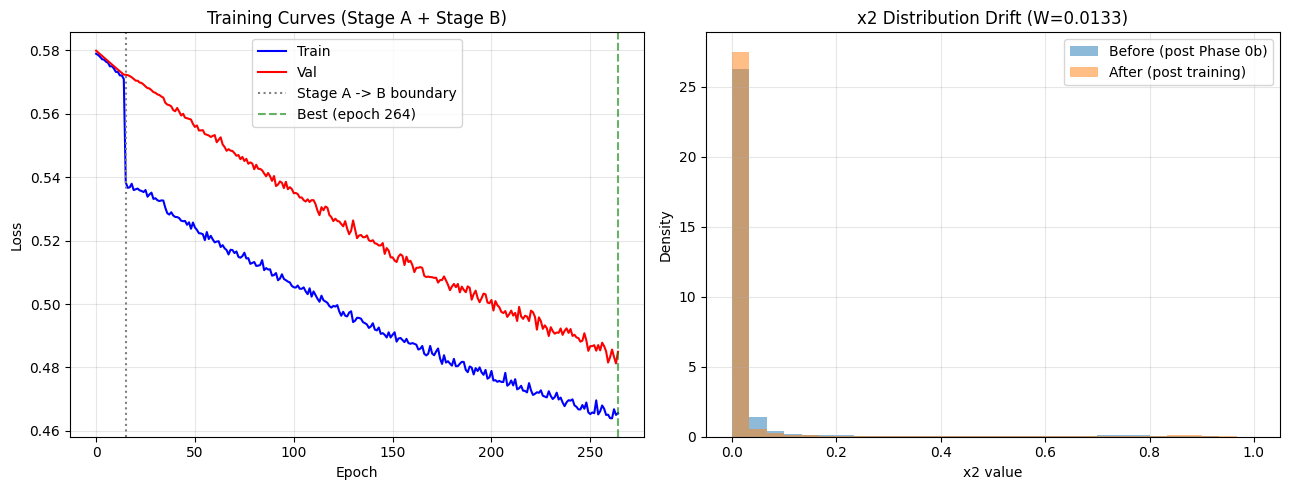

In [17]:
# [DRIFT-ANCHOR, added] Anchor targets for L_drift, computed once from the
# Phase-0b snapshot (x2_dist_before) -- the same distribution the FCM rules
# were fitted on. Plain floats, not tensors: these are fixed targets, never
# themselves trained.
X2_MEAN_ANCHOR = float(x2_dist_before.mean())
X2_STD_ANCHOR  = float(x2_dist_before.std())
print(f'[drift-anchor] targets captured: x2 mean={X2_MEAN_ANCHOR:.4f} std={X2_STD_ANCHOR:.4f}')


def set_trainable(params, trainable: bool):
    for p in params:
        p.requires_grad = trainable

def set_bn_eval(module):
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

def set_bn_train(module):
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.train()

encoder_modules = [model.enc1, model.enc2, model.enc3, model.enc4, model.bot]
decoder_modules = [model.smoe2, model.smoe3, model.smoe4,
                   model.up4, model.dec4, model.up3, model.dec3,
                   model.up2, model.dec2, model.up1, model.dec1, model.unet_head]


def train_one_epoch_stageA(model, loader, optimizer, criterion, device):
    model.train()
    for m in encoder_modules + decoder_modules:
        set_bn_eval(m)
    running = 0.0
    for imgs, masks, _ in tqdm(loader, desc='  StageA train', leave=False):
        imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad()
        prob, _, _, _, _, _ = model(imgs)
        if prob.dim() == 3: prob = prob.unsqueeze(1)
        loss = criterion(prob, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()
        running += loss.item()
    return running / len(loader)


def train_one_epoch_stageB(model, loader, optimizer, criterion, device, alpha, encoder_frozen, drift_active):
    model.train()
    if encoder_frozen:
        for m in encoder_modules:
            set_bn_eval(m)
    else:
        for m in encoder_modules:
            set_bn_train(m)
    for m in decoder_modules:
        set_bn_train(m)

    running, running_drift = 0.0, 0.0
    for imgs, masks, _ in tqdm(loader, desc='  StageB train', leave=False):
        imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad()
        prob, _, x2, _, unet_logits, _ = model(imgs)
        if prob.dim() == 3: prob = prob.unsqueeze(1)
        l_backbone = criterion(torch.sigmoid(unet_logits), masks)
        l_anfis    = criterion(prob, masks)

        # [DRIFT-ANCHOR, added] Only meaningful once x2_head is actually
        # trainable -- while frozen, x2 physically cannot move, so this would
        # just be near-constant noise in the loss. Anchors x2's batch mean/std
        # back toward the Phase-0b snapshot instead of letting it drift freely
        # once unfrozen (this is what turns "delayed unfreeze" into "delayed
        # AND then gently held in place", the missing half of the fix).
        if drift_active:
            l_drift = (x2.mean() - X2_MEAN_ANCHOR).abs() + (x2.std() - X2_STD_ANCHOR).abs()
        else:
            l_drift = torch.zeros((), device=device)

        loss = alpha * l_backbone + (1 - alpha) * l_anfis + LAMBDA_DRIFT * l_drift
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()
        running += loss.item()
        running_drift += l_drift.item()
    return running / len(loader), running_drift / len(loader)


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running = 0.0
    with torch.no_grad():
        for imgs, masks, _ in tqdm(loader, desc='  val', leave=False):
            masks = masks.to(device, non_blocking=True)
            pred  = predict_native(model, imgs, device, which='anfis')
            running += criterion(pred, masks).item()
    return running / len(loader)


@torch.no_grad()
def print_rule_diagnostics(model, loader, device, n_batches=15, tag=''):
    wbars = []
    model.eval()
    for i, (imgs, _, _) in enumerate(loader):
        if i >= n_batches: break
        imgs_pad, H, W = pad_to_multiple(imgs.to(device), multiple=PAD_MULTIPLE)
        _, wbar, _, _, _, _ = model(imgs_pad)
        wbars.append(wbar[..., :H, :W].cpu())
    mean_w, max_w, dom_pct = rule_activation_diagnostics(wbars)
    print(f'  [rule diagnostics{tag}] ' +
          '  '.join(f'R{k+1}: fire={mean_w[k]:.2f} dom={dom_pct[k]:.0f}%' for k in range(len(mean_w))))
    if dom_pct.max() > 95:
        print('    WARNING: possible rule collapse (one rule >95% dominant).')


# [ADDED] Resume support: restore model/optimizer/scheduler state, loss
# history, best-weight tracking, and which stage/epoch to resume at, from
# a checkpoint if one exists. The existing in-memory best_state_dict
# tracking below is unchanged -- this only adds where it can be restored
# FROM after a session restart.
_train_ckpt = load_checkpoint('training_state.pt')
if _train_ckpt is not None:
    model.load_state_dict(_train_ckpt['model_state'])
    optimizer.load_state_dict(_train_ckpt['optimizer_state'])
    scheduler.load_state_dict(_train_ckpt['scheduler_state'])
    train_losses = _train_ckpt['train_losses']
    val_losses = _train_ckpt['val_losses']
    best_val_loss = _train_ckpt['best_val_loss']
    best_epoch = _train_ckpt['best_epoch']
    best_state_dict = _train_ckpt['best_state_dict']
    _patience_ctr_resume = _train_ckpt['patience_ctr']
    if _train_ckpt['stage'] == 'A':
        _stageA_start_epoch = _train_ckpt['epoch'] + 1
        _stageB_start_epoch = 1
    else:
        _stageA_start_epoch = FROZEN_BASELINE_EPOCHS + 1
        _stageB_start_epoch = _train_ckpt['epoch'] + 1
    print(f"[resume] Training restored from checkpoint -- stage={_train_ckpt['stage']} "
          f"epoch={_train_ckpt['epoch']} best_val_loss={best_val_loss:.4f}")
else:
    train_losses, val_losses = [], []
    best_val_loss, best_epoch = float('inf'), 0
    best_state_dict = None   # kept IN MEMORY, same as before [UNCHANGED]
    _patience_ctr_resume = 0
    _stageA_start_epoch = 1
    _stageB_start_epoch = 1

# ---------------------------------------------------------------------------
# STAGE A -- frozen baseline
# ---------------------------------------------------------------------------
print('='*72)
print(f'STAGE A -- genuinely frozen backbone baseline ({FROZEN_BASELINE_EPOCHS} epochs)')
print('='*72)
set_trainable(encoder_params, False)
set_trainable(decoder_params, False)
set_trainable(anfis_params,   True)
set_trainable(mf_params,      True)

for epoch in range(_stageA_start_epoch, FROZEN_BASELINE_EPOCHS + 1):
    model.anfis_head.update_sigma_ceiling()   # sigma ceiling: refresh from current centers
    tl = train_one_epoch_stageA(model, loader_train, optimizer, criterion, DEVICE)
    vl = validate_epoch(model, loader_val, criterion, DEVICE)
    train_losses.append(tl); val_losses.append(vl)
    print(f'  [StageA] epoch {epoch:3d}/{FROZEN_BASELINE_EPOCHS}  train={tl:.4f}  val={vl:.4f}')
    if vl < best_val_loss:
        best_val_loss, best_epoch = vl, epoch
        best_state_dict = copy.deepcopy(model.state_dict())   # in-memory only [UNCHANGED]

    # [ADDED] per-epoch checkpoint save point (Stage A)
    save_checkpoint({
        'stage': 'A', 'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'train_losses': train_losses, 'val_losses': val_losses,
        'best_val_loss': best_val_loss, 'best_epoch': best_epoch,
        'patience_ctr': 0, 'best_state_dict': best_state_dict,
    }, 'training_state.pt')

print(f'\nStage A complete. Best val loss so far: {best_val_loss:.4f}')

# ---------------------------------------------------------------------------
# STAGE B -- joint fine-tuning, gradual unfreeze
# ---------------------------------------------------------------------------
print('\n' + '='*72)
print(f'STAGE B -- joint fine-tuning, up to {MAX_EPOCHS} epochs, gradual unfreeze')
print('='*72)
set_trainable(decoder_params, False)   # FIX: was unconditionally True from epoch 1
set_trainable(x2_head_params, False)   # [DRIFT-ANCHOR, added] same protection as decoder_params
set_trainable(anfis_params,   True)
patience_ctr = _patience_ctr_resume   # [CHANGED] resume the counter instead of always 0

for epoch in range(_stageB_start_epoch, MAX_EPOCHS + 1):
    mf_frozen = epoch <= MF_FREEZE_EPOCHS
    set_trainable(mf_params, not mf_frozen)

    encoder_frozen = epoch <= ENCODER_UNFREEZE_EPOCH
    set_trainable(encoder_params, not encoder_frozen)

    # FIX: decoder (unet_head -> x2) now protected on its own schedule instead
    # of being trainable from Stage-B epoch 1 -- this was the earliest, most
    # direct source of x2 drift relative to the FCM-fitted geometry.
    decoder_frozen = epoch <= DECODER_UNFREEZE_EPOCH
    set_trainable(decoder_params, not decoder_frozen)
    set_trainable(x2_head_params, not decoder_frozen)   # [DRIFT-ANCHOR, added]

    model.anfis_head.update_sigma_ceiling()   # sigma ceiling: refresh from current centers

    if epoch == 1:
        print(f'  MF params frozen for Stage-B epochs 1-{MF_FREEZE_EPOCHS}')
        print(f'  Encoder frozen (weights+BN) for Stage-B epochs 1-{ENCODER_UNFREEZE_EPOCH}, '
              f'then unfreezes at lr={LR_ENCODER}')
        print(f'  Decoder (smoe/up/dec) frozen for Stage-B epochs 1-{DECODER_UNFREEZE_EPOCH}, '
              f'then unfreezes at lr={LR_DECODER}')
        print(f'  [DRIFT-ANCHOR] x2_head (unet_head) frozen for Stage-B epochs 1-{DECODER_UNFREEZE_EPOCH}, '
              f'then unfreezes at lr={LR_X2_HEAD} (10x smaller than decoder) with L_drift active '
              f'(lambda={LAMBDA_DRIFT}, anchored to x2 mean={X2_MEAN_ANCHOR:.4f} std={X2_STD_ANCHOR:.4f})')
    if epoch == ENCODER_UNFREEZE_EPOCH + 1:
        print(f'  >>> Encoder unfrozen at Stage-B epoch {epoch} (lr={LR_ENCODER})')
    if epoch == DECODER_UNFREEZE_EPOCH + 1:
        print(f'  >>> Decoder unfrozen at Stage-B epoch {epoch} (lr={LR_DECODER})')
        print(f'  >>> [DRIFT-ANCHOR] x2_head unfrozen at Stage-B epoch {epoch} '
              f'(lr={LR_X2_HEAD}, L_drift now active)')

    tl, drift_avg = train_one_epoch_stageB(model, loader_train, optimizer, criterion, DEVICE,
                                ALPHA_BACKBONE, encoder_frozen, drift_active=not decoder_frozen)
    vl = validate_epoch(model, loader_val, criterion, DEVICE)
    train_losses.append(tl); val_losses.append(vl)
    scheduler.step(vl)

    if vl < best_val_loss:
        best_val_loss, best_epoch, patience_ctr = vl, len(train_losses), 0
        best_state_dict = copy.deepcopy(model.state_dict())   # in-memory only [UNCHANGED]
        status = 'BEST'
    else:
        patience_ctr += 1
        status = f'pat {patience_ctr}/{PATIENCE}'

    # [ADDED] per-epoch checkpoint save point (Stage B)
    save_checkpoint({
        'stage': 'B', 'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'train_losses': train_losses, 'val_losses': val_losses,
        'best_val_loss': best_val_loss, 'best_epoch': best_epoch,
        'patience_ctr': patience_ctr, 'best_state_dict': best_state_dict,
    }, 'training_state.pt')

    if epoch % 10 == 0 or epoch == 1:
        lrs = [f'{g["name"]}={g["lr"]:.1e}' for g in optimizer.param_groups]
        print(f'  [StageB] epoch {epoch:4d} train={tl:.4f} val={vl:.4f} {" ".join(lrs)}  {status}')

    # [DRIFT-ANCHOR, added] Live drift-loss trend, separate from the final
    # before/after Wasserstein report -- lets you see whether L_drift is
    # actually shrinking (x2 settling near its anchor) or growing (anchor
    # too weak / LR_X2_HEAD still too high) well before training finishes.
    if not decoder_frozen and epoch % DRIFT_REPORT_EVERY_N_EPOCHS == 0:
        print(f'  [drift-anchor] epoch {epoch:4d}  L_drift={drift_avg:.5f}  '
              f'(target x2 mean={X2_MEAN_ANCHOR:.4f} std={X2_STD_ANCHOR:.4f})')

    if epoch % RULE_DIAG_EVERY_N_EPOCHS == 0:
        print_rule_diagnostics(model, loader_val, DEVICE, tag=f' @ StageB epoch {epoch}')
        log_rule_geometry(model.anfis_head, tag=f' @ StageB epoch {epoch}')

    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping at Stage-B epoch {epoch}')
        break

# Restore best weights (in-memory swap, nothing written to disk)
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
print(f'\nBest val loss: {best_val_loss:.4f} at global epoch {best_epoch} (best weights restored from memory)')

# Step 1: verify the restored weights genuinely belong to THIS run, not a
# stale reference -- prints a checksum of the loaded state_dict plus the
# actual consequent/sigma-ceiling values, so results can be compared across
# runs to confirm they differ when training genuinely differs. Read-only.
_state_bytes = b''.join(p.detach().cpu().numpy().tobytes() for p in model.parameters())
_state_checksum = hashlib.md5(_state_bytes).hexdigest()[:12]
print(f'Loaded-weights checksum: {_state_checksum}  (best_epoch={best_epoch})')
log_rule_geometry(model.anfis_head, tag=' (post-training, restored best weights)')
print(f'ANFIS consequents (restored):\n{model.anfis_head.consequents.detach().cpu().numpy()}')

# Feature-drift snapshot AFTER training (compare against the Phase-0b baseline)
with torch.no_grad():
    x2_after_list = []
    for i, (imgs, _, _) in enumerate(loader_val):
        if i >= FEATURE_DRIFT_N_BATCHES: break
        imgs_pad, H, W = pad_to_multiple(imgs.to(DEVICE), multiple=PAD_MULTIPLE)
        _, _, x2_map, _, _, _ = model(imgs_pad)
        x2_after_list.append(x2_map[..., :H, :W].cpu().flatten())
x2_dist_after = torch.cat(x2_after_list).numpy()

w_dist = wasserstein_distance(x2_dist_before, x2_dist_after)
hist_before, edges = np.histogram(x2_dist_before, bins=30, range=(0,1), density=True)
hist_after, _      = np.histogram(x2_dist_after,  bins=edges, density=True)
kl = float(np.sum(np.where(hist_before > 0,
                           hist_before * np.log((hist_before + 1e-8) / (hist_after + 1e-8)), 0)) * (edges[1]-edges[0]))

print('\n' + '='*72)
print('FEATURE-DRIFT REPORT -- x2 = sigmoid(unet_logits), before vs after backbone fine-tuning')
print('='*72)
print(f'  Before (post Phase-0b) : mean={x2_dist_before.mean():.4f}  std={x2_dist_before.std():.4f}')
print(f'  After  (post training) : mean={x2_dist_after.mean():.4f}  std={x2_dist_after.std():.4f}')
print(f'  Wasserstein distance   : {w_dist:.4f}')
print(f'  Approx. KL(before||after): {kl:.4f}')
if w_dist > 0.05:
    print('  NOTE: noticeable drift -- the FCM rule geometry was fit on a feature')
    print('  space that has since moved; consider a smaller LR_ENCODER or an')
    print('  earlier ENCODER_UNFREEZE_EPOCH if downstream metrics look off.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(train_losses, 'b-', lw=1.5, label='Train')
axes[0].plot(val_losses,   'r-', lw=1.5, label='Val')
axes[0].axvline(FROZEN_BASELINE_EPOCHS, color='gray', ls=':', label='Stage A -> B boundary')
axes[0].axvline(best_epoch, color='g', ls='--', alpha=0.6, label=f'Best (epoch {best_epoch})')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Curves (Stage A + Stage B)')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(x2_dist_before, bins=30, range=(0,1), alpha=0.5, label='Before (post Phase 0b)', density=True)
axes[1].hist(x2_dist_after,  bins=30, range=(0,1), alpha=0.5, label='After (post training)', density=True)
axes[1].set(xlabel='x2 value', ylabel='Density', title=f'x2 Distribution Drift (W={w_dist:.4f})')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/training_curves_and_drift.png', dpi=150)
plt.show()


## Cell — Evaluation: ODS / OIS / AP (official protocol)
### Now evaluates BOTH the ANFIS head and the raw backbone (`P_backbone` vs
### `P_ANFIS`), so the direct-GT-training claim can be checked empirically.


In [ ]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial  import cKDTree
from scipy.sparse   import coo_matrix
from scipy.sparse.csgraph import connected_components
import glob, concurrent.futures

N_WORKERS = min(os.cpu_count() or 4, 4)
MAX_PRED  = 15000

def load_gt_boundaries(mat_path):
    boundaries = []
    try:
        mat = scipy.io.loadmat(mat_path, squeeze_me=True)
        gt_cell = mat['groundTruth']
        if gt_cell.ndim == 0:
            gt_cell = gt_cell.reshape(1)
        for ann in gt_cell.flat:
            try:
                b = ann['Boundaries'] if isinstance(ann, np.void) else ann[()]['Boundaries']
            except (KeyError, TypeError, IndexError):
                b = ann[0, 0][1] if hasattr(ann, '__getitem__') else ann.Boundaries
            if hasattr(b, 'toarray'):
                b = b.toarray()
            boundaries.append(b.astype(np.float32))
        return boundaries
    except Exception:
        return []


def _sparse_bipartite_tp(pred_yx, gt_yx, gt_tree, maxDist):
    n_pred = len(pred_yx); n_gt = len(gt_yx)
    if n_pred == 0 or n_gt == 0:
        return 0.0
    neighbors = gt_tree.query_ball_point(pred_yx, r=maxDist)
    pred_idx_list, gt_idx_list, dist_list = [], [], []
    for pi, gts in enumerate(neighbors):
        if not gts: continue
        gy = gt_yx[gts]
        d  = np.sqrt(((gy - pred_yx[pi]) ** 2).sum(-1))
        for gj, dd in zip(gts, d):
            pred_idx_list.append(pi); gt_idx_list.append(gj); dist_list.append(dd)
    if not pred_idx_list:
        return 0.0
    pred_idx_arr = np.array(pred_idx_list); gt_idx_arr = np.array(gt_idx_list)
    dist_arr = np.array(dist_list)
    n_total = n_pred + n_gt
    rows = np.concatenate([pred_idx_arr, gt_idx_arr + n_pred])
    cols = np.concatenate([gt_idx_arr + n_pred, pred_idx_arr])
    data = np.ones(len(rows))
    graph = coo_matrix((data, (rows, cols)), shape=(n_total, n_total))
    _, labels = connected_components(graph, directed=False)
    pred_labels = labels[:n_pred]
    edge_comp = pred_labels[pred_idx_arr]
    tp = 0.0
    for comp_id in np.unique(edge_comp):
        mask = edge_comp == comp_id
        p_local_ids = np.unique(pred_idx_arr[mask]); g_local_ids = np.unique(gt_idx_arr[mask])
        p_map = {p: k for k, p in enumerate(p_local_ids)}
        g_map = {g: k for k, g in enumerate(g_local_ids)}
        r, c = len(p_local_ids), len(g_local_ids)
        cost = np.full((r, c), 1e9)
        for p, g, d in zip(pred_idx_arr[mask], gt_idx_arr[mask], dist_arr[mask]):
            cost[p_map[p], g_map[g]] = d
        row_ind, col_ind = linear_sum_assignment(cost)
        valid = cost[row_ind, col_ind] < maxDist
        tp += float(valid.sum())
    return tp


def bipartite_counts_at_thresholds(prob, gt_boundaries, thresholds):
    H, W = prob.shape
    maxDist = max(0.0075 * max(H, W), 1.0)
    n_thresh = len(thresholds)
    gt_stack = np.stack(gt_boundaries, axis=0)
    gt_union = (gt_stack.max(axis=0) > 0.5).astype(bool)
    n_gt = int(gt_union.sum())
    tp_arr = np.zeros(n_thresh); fp_arr = np.zeros(n_thresh); fn_arr = np.zeros(n_thresh)
    if n_gt == 0:
        for i, t in enumerate(thresholds):
            fp_arr[i] = float((prob >= t).sum())
        return tp_arr, fp_arr, fn_arr
    gt_yx = np.column_stack(np.where(gt_union)).astype(np.float32)
    gt_tree = cKDTree(gt_yx)
    for i, t in enumerate(thresholds):
        pred_edge = (prob >= t)
        if not pred_edge.any():
            fn_arr[i] = float(n_gt); continue
        pred_yx = np.column_stack(np.where(pred_edge)).astype(np.float32)
        if len(pred_yx) > MAX_PRED:
            # FIX: previously kept the MAX_PRED predictions CLOSEST TO GROUND
            # TRUTH (oracle selection -- uses the answer to pick which pixels
            # count, inflating ODS/OIS/AP). Now keeps the MAX_PRED pixels with
            # the HIGHEST PREDICTED CONFIDENCE, matching what a real detector
            # would report at deployment -- no ground-truth information used.
            pred_conf = prob[pred_edge]
            keep_idx = np.argsort(-pred_conf)[:MAX_PRED]
            pred_yx = pred_yx[keep_idx]
        n_pred = len(pred_yx)
        tp = _sparse_bipartite_tp(pred_yx, gt_yx, gt_tree, maxDist)
        fp_arr[i] = float(n_pred) - tp
        fn_arr[i] = float(n_gt) - tp
        tp_arr[i] = tp
    return tp_arr, fp_arr, fn_arr


def _image_counts_worker(args):
    prob, mat_path, gt_fallback, thresholds = args
    if mat_path and os.path.exists(mat_path):
        gt_bnd = load_gt_boundaries(mat_path)
    else:
        gt_bnd = None
    if not gt_bnd:
        gt_bnd = [gt_fallback]
    return bipartite_counts_at_thresholds(prob, gt_bnd, thresholds)


def compute_unified_metrics(model, loader, device, n_thresh=99, which='anfis'):
    model.eval()
    thresholds = np.linspace(0.01, 0.99, n_thresh)
    gt_dir = os.path.join(BSR_ROOT, 'data', 'groundTruth', 'test')
    job_args = []
    with torch.no_grad():
        for imgs, masks, stems in tqdm(loader, desc=f'Inference ({which})'):
            pred = predict_native(model, imgs, device, which=which)
            prob = pred.squeeze().cpu().numpy()
            gt_b = (masks.squeeze().cpu().numpy() > 0.5).astype(np.float32)
            stem = stems[0] if isinstance(stems, (list, tuple)) else stems
            mat_path = os.path.join(gt_dir, f'{stem}.mat')
            job_args.append((prob, mat_path, gt_b, thresholds))

    with concurrent.futures.ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        per_image_counts = list(tqdm(ex.map(_image_counts_worker, job_args),
                                     total=len(job_args), desc=f'Matching ({which})'))

    all_tp = np.zeros(n_thresh); all_fp = np.zeros(n_thresh); all_fn = np.zeros(n_thresh)
    for tp_arr, fp_arr, fn_arr in per_image_counts:
        all_tp += tp_arr; all_fp += fp_arr; all_fn += fn_arr
    precs = all_tp / (all_tp + all_fp + 1e-8)
    recs  = all_tp / (all_tp + all_fn + 1e-8)
    fscs  = 2 * precs * recs / (precs + recs + 1e-8)
    best_i = int(np.argmax(fscs))
    ODS = float(fscs[best_i]); best_t = float(thresholds[best_i])

    per_image_best_f = []
    for tp_arr, fp_arr, fn_arr in per_image_counts:
        p_i = tp_arr / (tp_arr + fp_arr + 1e-8); r_i = tp_arr / (tp_arr + fn_arr + 1e-8)
        f_i = 2 * p_i * r_i / (p_i + r_i + 1e-8)
        per_image_best_f.append(float(f_i.max()))
    OIS = float(np.mean(per_image_best_f))

    # [FIXED] AP is now the area under the single AGGREGATED precision-
    # recall curve (pooled all_tp/all_fp/all_fn across the whole test set --
    # the same curve ODS is read from above), matching the standard BSDS500
    # / edge-detection-literature AP definition used by the base paper.
    # Previously this was the MEAN of each image's own per-image AP, a
    # different (detection-mAP-style) quantity not directly comparable to
    # the paper's reported AP=0.7222.
    order = np.argsort(recs)
    try:
        AP = float(auc(recs[order], precs[order]))
    except ValueError:
        AP = 0.0
    return ODS, OIS, AP, precs, recs, best_t


print('Computing metrics on test set (ANFIS head)...')
ODS, OIS, AP, precs, recs, best_t = compute_unified_metrics(model, loader_test, DEVICE, which='anfis')
print(f'ANFIS    ODS={ODS:.4f}  OIS={OIS:.4f}  AP={AP:.4f}  best_t={best_t:.3f}')

ODS_bb = OIS_bb = AP_bb = None
if EVALUATE_BACKBONE_BASELINE:
    print('\nComputing metrics on test set (raw backbone, P_backbone = sigmoid(unet_logits))...')
    ODS_bb, OIS_bb, AP_bb, precs_bb, recs_bb, best_t_bb = compute_unified_metrics(
        model, loader_test, DEVICE, which='backbone')
    print(f'Backbone ODS={ODS_bb:.4f}  OIS={OIS_bb:.4f}  AP={AP_bb:.4f}  best_t={best_t_bb:.3f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recs, precs, 'b-', lw=2.5, label=f'ANFIS  ODS={ODS:.4f}  AP={AP:.4f}')
if EVALUATE_BACKBONE_BASELINE:
    ax.plot(recs_bb, precs_bb, 'r--', lw=2, label=f'Backbone  ODS={ODS_bb:.4f}  AP={AP_bb:.4f}')
ax.set(xlabel='Recall', ylabel='Precision', title='PR Curve -- BSDS500 Test',
       xlim=[0,1], ylim=[0,1.05])
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/pr_curve.png', dpi=150)
plt.show()


Computing metrics on test set (ANFIS head)...


Matching (anfis): 100%|██████████| 200/200 [2:01:14<00:00, 36.37s/it]  


ANFIS    ODS=0.5720  OIS=0.5750  AP=0.4858  best_t=0.100

Computing metrics on test set (raw backbone, P_backbone = sigmoid(unet_logits))...


Matching (backbone):  80%|███████▉  | 159/200 [1:31:15<32:18, 47.28s/it]  

## Cell — Metric Comparison Table (paper baseline vs backbone-this-run vs ANFIS-this-run)

In [ ]:
print('='*76)
print('  COMPARISON: Paper-Reported Baseline vs This Run (Backbone and ANFIS)')
print('='*76)
paper_ods, paper_ois, paper_ap = 0.7628, 0.7458, 0.7222
print(f'  {"Metric":<10} {"Paper Table 1":>16} {"Backbone (this run)":>20} {"ANFIS (this run)":>18}')
print('-'*76)
for name, paper_v, bb_v, anfis_v in [('ODS', paper_ods, ODS_bb, ODS),
                                      ('OIS', paper_ois, OIS_bb, OIS),
                                      ('AP',  paper_ap,  AP_bb,  AP)]:
    bb_str = f'{bb_v:.4f}' if bb_v is not None else 'n/a'
    print(f'  {name:<10} {paper_v:>16.4f} {bb_str:>20} {anfis_v:>18.4f}')
print('-'*76)
if ODS_bb is not None:
    print(f'  ANFIS vs Backbone gain (this run): ODS {ODS-ODS_bb:+.4f}  OIS {OIS-OIS_bb:+.4f}  AP {AP-AP_bb:+.4f}')
    print('  (This is the direct empirical evidence for the direct-GT-training claim --')
    print('   ANFIS is trained against ground truth, not distilled from the backbone,')
    print('   so it should be able to exceed backbone-only performance.)')
print('='*76)


## Cell — Qualitative Results (unchanged)

In [ ]:
def denorm(t):
    mean = torch.tensor([0.485,0.456,0.406], device=t.device).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225], device=t.device).view(3,1,1)
    return (t*std+mean).clamp(0,1).permute(1,2,0).cpu().numpy()

model.eval()
N = min(6, len(ds_test))
samples = []
with torch.no_grad():
    for i, (img, mask, stem) in enumerate(loader_test):
        if i >= N: break
        pred = predict_native(model, img, DEVICE, which='anfis')
        if pred.dim() == 3: pred = pred.unsqueeze(1)
        samples.append((img.cpu(), mask.cpu(), pred.cpu(), stem[0]))

fig, axes = plt.subplots(N, 3, figsize=(12, 4*N))
titles = ['Input', 'Ground Truth', 'Prediction']
fig.suptitle('ANFIS-FCM sMoE U-Net -- BSDS500 Test', fontsize=13, fontweight='bold')
for row, (img, mask, pred, stem) in enumerate(samples):
    axes[row,0].imshow(denorm(img[0]))
    axes[row,1].imshow(mask[0,0].numpy(), cmap='gray')
    axes[row,2].imshow(pred[0,0].numpy(), cmap='hot')
    for col in range(3):
        axes[row,col].axis('off')
        if row == 0:
            axes[row,col].set_title(titles[col], fontsize=11, fontweight='bold')
    axes[row,0].set_ylabel(stem, fontsize=8, rotation=0, labelpad=60)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/qualitative_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
def denorm(t):
    mean = torch.tensor([0.485,0.456,0.406], device=t.device).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225], device=t.device).view(3,1,1)
    return (t*std+mean).clamp(0,1).permute(1,2,0).cpu().numpy()

model.eval()

# Option 4: Specify exact indices you want to see
INDICES_TO_SHOW = [110, 27, 76, 34, 29, 46, 96, 89, 156, 140, 193]  # Change these numbers
N = len(INDICES_TO_SHOW)

samples = []
with torch.no_grad():
    for idx in INDICES_TO_SHOW:
        img, mask, stem = ds_test[idx]
        img = img.unsqueeze(0)  # Add batch dimension
        mask = mask.unsqueeze(0)
        
        pred = predict_native(model, img, DEVICE)
        if pred.dim() == 3: 
            pred = pred.unsqueeze(1)
        samples.append((img.cpu(), mask.cpu(), pred.cpu(), stem))

fig, axes = plt.subplots(N, 3, figsize=(12, 4*N))
titles = [' Input ', ' Ground Truth ' , ' Prediction ' ]
fig.suptitle(f'sMoE U-Net — BSDS500 Test (custom indices: {INDICES_TO_SHOW})',
             fontsize=13, fontweight='bold')
for row, (img, mask, pred, stem) in enumerate(samples):
    axes[row,0].imshow(denorm(img[0]))
    axes[row,1].imshow(mask[0,0].numpy(), cmap='gray')
    axes[row,2].imshow(pred[0,0].numpy(), cmap='hot')
    for col in range(3):
        axes[row,col].axis('off')
        if row == 0:
            axes[row,col].set_title(titles[col], fontsize=11, fontweight='bold')
    axes[row,0].set_ylabel(f"#{INDICES_TO_SHOW[row]}: {stem}", fontsize=8, rotation=0, labelpad=60)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/qualitative_results_custom.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Qualitative results saved for indices: {INDICES_TO_SHOW}')

## Cell — ANFIS Rule Firing Maps + Entropy Map (R*, native XAI)

In [ ]:
model.eval()
_imgs, _masks, _stems = next(iter(loader_test))
_imgs_pad, H0, W0 = pad_to_multiple(_imgs.to(DEVICE), multiple=PAD_MULTIPLE)

with torch.no_grad():
    out = model(_imgs_pad)

prob, rule_maps, x2_map, edge_sig, _, x1_map = out
prob      = prob[..., :H0, :W0]
rule_maps = rule_maps[..., :H0, :W0]
edge_sig  = edge_sig[..., :H0, :W0]
x1_map    = x1_map[..., :H0, :W0]
x2_map    = x2_map[..., :H0, :W0]

img_disp  = denorm(_imgs[0])
pred_disp = prob[0].cpu().numpy()
if pred_disp.ndim == 3 and pred_disp.shape[0] == 1:
    pred_disp = pred_disp.squeeze(0)
edge_disp = edge_sig[0,0].cpu().numpy()
rw        = rule_maps[0].cpu()
R         = rw.shape[0]
entropy_map = rule_entropy_map(rule_maps)[0,0].cpu().numpy()   # new: uncertainty map

n_panels = R + 5
n_cols   = 4
n_rows   = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = np.array(axes).reshape(-1)
fig.suptitle(f'ANFIS Rule Firing Maps -- R*={R} data-driven rules', fontsize=13, fontweight='bold')

axes[0].imshow(img_disp); axes[0].set_title('Input'); axes[0].axis('off')

cmap_cycle = plt.cm.tab10(np.linspace(0, 1, max(R, 10)))
for k in range(R):
    ax = axes[k+1]
    rmap = rw[k].numpy()
    vmax = max(float(np.percentile(rmap, 99)), 1e-3)
    im = ax.imshow(rmap, cmap='Reds', vmin=0, vmax=vmax)
    ax.set_title(f'Rule {k+1} firing', fontsize=9); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

dom = rw.argmax(dim=0).numpy()
ax_dom = axes[R+1]
cmap_dom = ListedColormap([cmap_cycle[k] for k in range(R)])
im_dom = ax_dom.imshow(dom, cmap=cmap_dom, vmin=0, vmax=R-1)
ax_dom.set_title('Dominant Rule (argmax)'); ax_dom.axis('off')
cbar = plt.colorbar(im_dom, ax=ax_dom, fraction=0.046, pad=0.04, ticks=range(R))
cbar.set_ticklabels([f'R{k+1}' for k in range(R)])

im_ent = axes[R+2].imshow(entropy_map, cmap='viridis')
axes[R+2].set_title('Rule Entropy (uncertainty)'); axes[R+2].axis('off')
plt.colorbar(im_ent, ax=axes[R+2], fraction=0.046, pad=0.04)

axes[R+3].imshow(edge_disp, cmap='gray')
axes[R+3].set_title('Sobel E (x1)'); axes[R+3].axis('off')

im_out = axes[R+4].imshow(pred_disp, cmap='hot')
axes[R+4].set_title('ANFIS Output (probability)'); axes[R+4].axis('off')
plt.colorbar(im_out, ax=axes[R+4], fraction=0.046, pad=0.04)

for ax in axes[n_panels:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/rule_firing_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ANFIS rule firing maps + entropy map saved (R*={R} rules)')


## Cell — Rule Contribution Maps
Distinct from firing maps: a rule can fire strongly (`wbar` high) yet
contribute negatively to the final prediction if its consequent `(p,q,r)` is
negative -- e.g. actively suppressing a false texture edge. Firing alone
can't show that; contribution `wbar_i * TSK_i(x)` can.


In [ ]:
contrib = rule_contribution_maps(model.anfis_head, x1_map, x2_map, rule_maps)[0].cpu()  # [R,H,W]
vmax_c = float(np.percentile(np.abs(contrib.numpy()), 99)) or 1e-3

n_cols = 4
n_rows = int(np.ceil(R / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = np.array(axes).reshape(-1)
fig.suptitle(f'ANFIS Rule Contribution Maps -- w̄_i x TSK_i(x)  (R*={R})', fontsize=13, fontweight='bold')
for k in range(R):
    im = axes[k].imshow(contrib[k].numpy(), cmap='RdBu_r', vmin=-vmax_c, vmax=vmax_c)
    axes[k].set_title(f'Rule {k+1} contribution', fontsize=9); axes[k].axis('off')
    plt.colorbar(im, ax=axes[k], fraction=0.046, pad=0.04)
for ax in axes[R:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/rule_contribution_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Rule contribution maps saved -- blue/red indicate suppressing/reinforcing contribution')


## Cell — Rule Semantic Profiling Table
For each rule: mean x1, mean x2, mean GT edge probability, mean predicted
probability where that rule dominates, and a plain-language interpretation --
much more informative than a firing heatmap alone.


In [ ]:
print('Computing rule semantic profile over the test set (dominant-rule pixels only)...')
sums = {k: {'x1':0.0,'x2':0.0,'gt':0.0,'pred':0.0,'n':0} for k in range(R)}
model.eval()
with torch.no_grad():
    for imgs, masks, _ in tqdm(loader_test, desc='  profiling'):
        imgs_pad, H, W = pad_to_multiple(imgs.to(DEVICE), multiple=PAD_MULTIPLE)
        prob_t, wbar_t, x2_t, _, _, x1_t = model(imgs_pad)
        prob_t = prob_t[..., :H, :W]; wbar_t = wbar_t[..., :H, :W]
        x1_t = x1_t[..., :H, :W]; x2_t = x2_t[..., :H, :W]
        gt_t = F.interpolate(masks.to(DEVICE), size=(H, W), mode='nearest')
        dom_t = wbar_t.argmax(dim=1)
        for k in range(R):
            mask_k = (dom_t == k)
            if mask_k.sum() == 0: continue
            sums[k]['x1']   += x1_t[:,0][mask_k].sum().item()
            sums[k]['x2']   += x2_t[:,0][mask_k].sum().item()
            sums[k]['gt']   += gt_t[:,0][mask_k].sum().item()
            sums[k]['pred'] += prob_t.squeeze(1)[mask_k].sum().item()
            sums[k]['n']    += mask_k.sum().item()

def _interp(x1_lvl, x2_lvl):
    if x1_lvl == 'Low'  and x2_lvl == 'Low':  return 'Smooth background'
    if x1_lvl == 'High' and x2_lvl == 'Low':  return 'Texture / false edge'
    if x1_lvl == 'Low'  and x2_lvl == 'High': return 'Semantic boundary'
    return 'Strong true edge'

print(f'\n  {"Rule":<6} {"mean x1":>9} {"mean x2":>9} {"mean GT":>9} {"mean pred":>10} {"x1":>6} {"x2":>6}  Interpretation')
print('  ' + '-'*84)
for k in range(R):
    n = max(sums[k]['n'], 1)
    mx1, mx2 = sums[k]['x1']/n, sums[k]['x2']/n
    mgt, mpr = sums[k]['gt']/n, sums[k]['pred']/n
    x1_lvl = 'High' if mx1 > 0.5 else 'Low'
    x2_lvl = 'High' if mx2 > 0.5 else 'Low'
    interp = _interp(x1_lvl, x2_lvl)
    print(f'  R{k+1:<5} {mx1:>9.3f} {mx2:>9.3f} {mgt:>9.3f} {mpr:>10.3f} {x1_lvl:>6} {x2_lvl:>6}  {interp}')


## Cell — ANFIS Rule-Base Visualisation (softplus sigma, no clamp)

In [ ]:
x_range = np.linspace(0, 1, 200)
anfis_head = model.anfis_head
R = anfis_head.n_rules
theta = anfis_head.consequents.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'ANFIS Rule-Base -- R*={R}, FCM-initialised, softplus sigma, LSE-init + backprop-refined',
             fontsize=13, fontweight='bold')
colours = plt.cm.tab10(np.linspace(0, 1, max(R, 10)))

print(f'  {"Rule":<8} {"c_x1":>8} {"sigma_x1":>10} {"c_x2":>8} {"sigma_x2":>10} {"p":>8} {"q":>8} {"r":>8}')
print('  ' + '-'*76)

for i_r, rule in enumerate(anfis_head.rules):
    cx1 = rule.mf_x1.center.item(); sx1 = rule.mf_x1.sigma.item()
    cx2 = rule.mf_x2.center.item(); sx2 = rule.mf_x2.sigma.item()
    pv, qv, rv = theta[i_r]
    m1 = np.exp(-((x_range-cx1)**2)/(2*sx1**2+1e-8))
    m2 = np.exp(-((x_range-cx2)**2)/(2*sx2**2+1e-8))
    axes[0].plot(x_range, m1, color=colours[i_r], lw=2, label=f'R{i_r+1}')
    axes[1].plot(x_range, m2, color=colours[i_r], lw=2, label=f'R{i_r+1}')
    axes[2].scatter(cx1, cx2, s=220, color=colours[i_r], edgecolors='k', lw=1.5, zorder=5)
    axes[2].annotate(f'R{i_r+1}', (cx1+0.02, cx2+0.02), fontsize=9)
    print(f'  Rule {i_r+1:<4} {cx1:>8.3f} {sx1:>10.3f} {cx2:>8.3f} {sx2:>10.3f} '
          f'{pv:>8.3f} {qv:>8.3f} {rv:>8.3f}')

for ax, xl, title in [(axes[0],'Edge Strength (x1)','MFs for x1 -- Sobel Signal'),
                       (axes[1],'Semantic Conf. (x2)','MFs for x2 -- sigmoid(unet_logits)')]:
    ax.set(xlabel=xl, ylabel='Membership', title=title, xlim=[0,1], ylim=[0,1.05])
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

axes[2].axhline(0.5, color='gray', ls='--', alpha=0.4)
axes[2].axvline(0.5, color='gray', ls='--', alpha=0.4)
axes[2].set(xlabel='c_x1', ylabel='c_x2', title='Rule Centre Distribution (FCM)', xlim=[0,1], ylim=[0,1])
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/anfis_rule_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ANFIS rule-base + MF curve visualisation saved (R*={R})')
